# GB1 ESM-2 Architecture Sandbox

This notebook is a lightweight version of the original `ESM_Loading-2.ipynb` focused on **loading the already-computed ESM-2 embeddings** and recreating the exact k=5 feature inputs that were fed into the MLP at the bottom of the old notebook.

Main outputs:
- `X_k5_flat`: the final MLP-style feature matrix: **full-sequence mean embedding + flattened mutation-window embeddings**.
- `X_window_k5`: the unflattened mutation-window tensor for CNN/Transformer/attention-style architectures.
- `split_tensors_flat` and `split_tensors_window`: train/test tensors for `one_vs_rest`, `two_vs_rest`, and `three_vs_rest`.
- Literature/model comparison plots carried over from the original notebook.

## 1. Install packages

In Colab, PyTorch is usually already installed. This cell installs the common packages needed for this notebook. If the PyTorch install line causes compatibility issues, comment it out and restart the runtime.

In [1]:
# Core scientific stack
!pip -q install numpy pandas scipy scikit-learn matplotlib seaborn tqdm

# PyTorch is often pre-installed in Colab, but this keeps the notebook self-contained.
# If this causes CUDA/runtime compatibility issues, comment it out and restart the runtime.
!pip -q install torch torchvision torchaudio

# Optional: only needed if you later decide to regenerate ESM embeddings from sequences.
# !pip -q install fair-esm

## 2. Imports and device

In [2]:
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 3. Mount Drive and set paths

These paths are copied from the original notebook. Update `BASE_DIR` if your Drive folder changed.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/CBMF 4761 /FLIP/GB1')

EMB_PATH = BASE_DIR / 'gb1_esm2_embeddings.pt'      # full residue embeddings: X_residue
MEAN_PATH = BASE_DIR / 'gb1_esm2_mean.pt'           # optional cached sequence means
MUT_MEAN_PATH = BASE_DIR / 'gb1_esm2_mut_mean.pt'   # optional cached mutation-position means

print("BASE_DIR:", BASE_DIR)
print("Full embedding file exists:", EMB_PATH.exists())
print("Mean embedding file exists:", MEAN_PATH.exists())
print("Mut-mean embedding file exists:", MUT_MEAN_PATH.exists())

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1
Full embedding file exists: True
Mean embedding file exists: True
Mut-mean embedding file exists: True


## 4. Helper functions for loading embeddings

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_emb_obj(path):
    """Load a saved PyTorch embedding object on CPU."""
    return torch.load(path, map_location='cpu', weights_only=False)


def _get_first_existing(obj, keys):
    for key in keys:
        if key in obj:
            return obj[key]
    raise KeyError(f"None of these keys were found: {keys}. Available keys: {list(obj.keys())}")


def build_df_from_obj(obj, x_key='X'):
    """
    Rebuild the dataframe and feature array from the saved embedding object.
    The original notebook expected these metadata keys to be present in the .pt file.
    """
    df = pd.DataFrame({
        'Variants': _get_first_existing(obj, ['Variants', 'variant', 'variants']),
        'sequence': _get_first_existing(obj, ['sequence', 'Sequence', 'sequences']),
        'fitness': _get_first_existing(obj, ['fitness', 'Fitness']),
        'one_vs_rest': _get_first_existing(obj, ['one_vs_rest']),
        'two_vs_rest': _get_first_existing(obj, ['two_vs_rest']),
        'three_vs_rest': _get_first_existing(obj, ['three_vs_rest']),
    })
    X = to_numpy(obj[x_key])
    return df, X

## 5. Load the saved embeddings

This cell should be fast because it loads saved embeddings instead of regenerating ESM-2 representations.

In [5]:
full_emb = load_emb_obj(EMB_PATH)
print("Keys in full_emb:", list(full_emb.keys()))

df_full, X_full_residue = build_df_from_obj(full_emb, x_key='X_residue')

# Optional cached feature sets from the original notebook, if you want to compare later.
mean_emb = load_emb_obj(MEAN_PATH) if MEAN_PATH.exists() else None
mut_mean_emb = load_emb_obj(MUT_MEAN_PATH) if MUT_MEAN_PATH.exists() else None

print("df_full shape:", df_full.shape)
print("X_full_residue shape:", X_full_residue.shape)
print(df_full.head())
print(df_full[['one_vs_rest', 'two_vs_rest', 'three_vs_rest']].apply(lambda s: s.value_counts()))

Keys in full_emb: ['Variants', 'X_residue', 'sequence', 'fitness', 'one_vs_rest', 'two_vs_rest', 'three_vs_rest']
df_full shape: (8733, 6)
X_full_residue shape: (8733, 265, 640)
  Variants                                           sequence   fitness  \
0     VDGV  MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...  1.000000   
1     IDGV  MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGIDGEWTYD...  1.445905   
2     LDGV  MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLDGEWTYD...  1.690164   
3     MDGV  MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGMDGEWTYD...  1.170550   
4     VAGV  MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVAGEWTYD...  2.401243   

  one_vs_rest two_vs_rest three_vs_rest  
0       train       train         train  
1       train       train         train  
2       train       train         train  
3       train       train         train  
4       train       train         train  
       one_vs_rest  two_vs_rest  three_vs_rest
test          8705         8309           5743
train           28       

## 6. Recreate the exact k=5 MLP input and also keep a 2D/window tensor

From the old notebook, the final MLP sweep used:

```python
X_k5, feature_info, X_window_k5 = build_gb1_features_torch(
    X_full_residue=X_full_residue,
    mut_positions=[38, 39, 40, 53],
    k=5,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=True,
    as_torch=True,
)
```

So the actual MLP input was `X_k5`: a 2D flat feature matrix with shape `(n_samples, n_features)`. This notebook also keeps `X_window_k5` with shape `(n_samples, n_window_positions, embedding_dim)` for architectures that should preserve residue-window structure.

In [6]:
def get_window_positions(mut_positions, seq_len, k=5):
    """
    Build sorted unique residue positions consisting of each mutation position
    plus +/- k residues around each mutation position.
    """
    pos_set = set(mut_positions)
    for pos in mut_positions:
        for offset in range(1, k + 1):
            if pos - offset >= 0:
                pos_set.add(pos - offset)
            if pos + offset < seq_len:
                pos_set.add(pos + offset)
    return sorted(pos_set)


def build_gb1_features_torch(
    X_full_residue,
    mut_positions,
    k=5,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=False,
    as_torch=True,
    dtype=torch.float32,
):
    """
    Build GB1 feature tensors from residue-level ESM-2 embeddings.

    Returns
    -------
    X : torch.Tensor or np.ndarray
        Flat feature matrix. With the original final MLP settings, this is
        full-sequence mean embedding concatenated with flattened k=5 mutation-window embeddings.
    feature_info : dict
        Metadata describing the feature construction.
    X_window : torch.Tensor or np.ndarray, optional
        Unflattened local window tensor with shape (n_samples, n_window_positions, emb_dim).
    """
    X_np = to_numpy(X_full_residue)
    n_samples, seq_len, emb_dim = X_np.shape

    feature_blocks = []
    feature_names = []

    X_mean = X_np.mean(axis=1)
    if include_mean:
        feature_blocks.append(X_mean)
        feature_names.append('mean')

    if include_std:
        X_std = X_np.std(axis=1)
        feature_blocks.append(X_std)
        feature_names.append('std')

    window_positions = get_window_positions(mut_positions, seq_len, k=k)
    X_window = X_np[:, window_positions, :]  # (n_samples, n_window_positions, emb_dim)

    if include_window_flat:
        X_window_flat = X_window.reshape(n_samples, -1)
        feature_blocks.append(X_window_flat)
        feature_names.append('window_flat')

    if not feature_blocks:
        raise ValueError('At least one feature block must be included.')

    X = np.concatenate(feature_blocks, axis=1)

    feature_info = {
        'k': k,
        'mut_positions': list(mut_positions),
        'window_positions': window_positions,
        'n_window_positions': len(window_positions),
        'emb_dim': emb_dim,
        'feature_blocks': feature_names,
        'n_features': X.shape[1],
        'flat_feature_shape': X.shape,
        'window_tensor_shape': X_window.shape,
    }

    if as_torch:
        X = torch.tensor(X, dtype=dtype)
        X_window = torch.tensor(X_window, dtype=dtype)
        X_mean = torch.tensor(X_mean, dtype=dtype)

    if return_window_tensor:
        return X, feature_info, X_window, X_mean
    return X, feature_info

In [7]:
MUT_POSITIONS = [38, 39, 40, 53]
WINDOW_K = 5

X_k5_flat, feature_info, X_window_k5, X_seq_mean = build_gb1_features_torch(
    X_full_residue=X_full_residue,
    mut_positions=MUT_POSITIONS,
    k=WINDOW_K,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=True,
    as_torch=True,
)

print("Feature info:")
for k, v in feature_info.items():
    print(f"  {k}: {v}")

print("Main tensors:")
print("X_k5_flat shape       :", tuple(X_k5_flat.shape), "# same style as final MLP input")
print("X_window_k5 shape     :", tuple(X_window_k5.shape), "# unflattened mutation-window tensor")
print("X_seq_mean shape      :", tuple(X_seq_mean.shape), "# full-sequence mean only")

Feature info:
  k: 5
  mut_positions: [38, 39, 40, 53]
  window_positions: [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]
  n_window_positions: 24
  emb_dim: 640
  feature_blocks: ['mean', 'window_flat']
  n_features: 16000
  flat_feature_shape: (8733, 16000)
  window_tensor_shape: (8733, 24, 640)
Main tensors:
X_k5_flat shape       : (8733, 16000) # same style as final MLP input
X_window_k5 shape     : (8733, 24, 640) # unflattened mutation-window tensor
X_seq_mean shape      : (8733, 640) # full-sequence mean only


## 7. Build train/test splits for flat and window-style architectures

Use `split_tensors_flat` to reproduce the old MLP input. Use `split_tensors_window` for models that consume a residue-window tensor, such as 1D CNNs, attention pooling, or small Transformers. Use `split_tensors_hybrid` if you want a model that uses both a sequence-level mean branch and a local window branch.

In [8]:
def make_split_tensors(
    X,
    df,
    split_cols=('one_vs_rest', 'two_vs_rest', 'three_vs_rest'),
    target_col='fitness',
    device='cpu',
    dtype=torch.float32,
):
    """Build train/test tensors for each split."""
    if not torch.is_tensor(X):
        X = torch.tensor(X, dtype=dtype)

    y = torch.tensor(df[target_col].values, dtype=dtype)
    split_data = {}

    for split_name in split_cols:
        labels = df[split_name].astype(str).str.lower().str.strip()
        train_mask = torch.tensor((labels == 'train').values, dtype=torch.bool)
        test_mask = torch.tensor((labels == 'test').values, dtype=torch.bool)

        split_data[split_name] = {
            'X_train': X[train_mask].to(device),
            'y_train': y[train_mask].to(device),
            'X_test': X[test_mask].to(device),
            'y_test': y[test_mask].to(device),
            'train_mask': train_mask,
            'test_mask': test_mask,
        }

    return split_data


def make_hybrid_split_tensors(
    X_window,
    X_mean,
    df,
    split_cols=('one_vs_rest', 'two_vs_rest', 'three_vs_rest'),
    target_col='fitness',
    device='cpu',
    dtype=torch.float32,
):
    """Build train/test tensors for two-input models: local window branch + sequence mean branch."""
    if not torch.is_tensor(X_window):
        X_window = torch.tensor(X_window, dtype=dtype)
    if not torch.is_tensor(X_mean):
        X_mean = torch.tensor(X_mean, dtype=dtype)

    y = torch.tensor(df[target_col].values, dtype=dtype)
    split_data = {}

    for split_name in split_cols:
        labels = df[split_name].astype(str).str.lower().str.strip()
        train_mask = torch.tensor((labels == 'train').values, dtype=torch.bool)
        test_mask = torch.tensor((labels == 'test').values, dtype=torch.bool)

        split_data[split_name] = {
            'X_window_train': X_window[train_mask].to(device),
            'X_mean_train': X_mean[train_mask].to(device),
            'y_train': y[train_mask].to(device),
            'X_window_test': X_window[test_mask].to(device),
            'X_mean_test': X_mean[test_mask].to(device),
            'y_test': y[test_mask].to(device),
            'train_mask': train_mask,
            'test_mask': test_mask,
        }

    return split_data


split_tensors_flat = make_split_tensors(X_k5_flat, df_full, device='cpu')
split_tensors_window = make_split_tensors(X_window_k5, df_full, device='cpu')
split_tensors_hybrid = make_hybrid_split_tensors(X_window_k5, X_seq_mean, df_full, device='cpu')

for split_name in ['one_vs_rest', 'two_vs_rest', 'three_vs_rest']:
    flat = split_tensors_flat[split_name]
    window = split_tensors_window[split_name]
    hybrid = split_tensors_hybrid[split_name]
    print(f"{split_name}")
    print("  flat   :", tuple(flat['X_train'].shape), tuple(flat['X_test'].shape))
    print("  window :", tuple(window['X_train'].shape), tuple(window['X_test'].shape))
    print("  hybrid :", tuple(hybrid['X_window_train'].shape), tuple(hybrid['X_mean_train'].shape))

one_vs_rest
  flat   : (28, 16000) (8705, 16000)
  window : (28, 24, 640) (8705, 24, 640)
  hybrid : (28, 24, 640) (28, 640)
two_vs_rest
  flat   : (424, 16000) (8309, 16000)
  window : (424, 24, 640) (8309, 24, 640)
  hybrid : (424, 24, 640) (424, 640)
three_vs_rest
  flat   : (2990, 16000) (5743, 16000)
  window : (2990, 24, 640) (5743, 24, 640)
  hybrid : (2990, 24, 640) (2990, 640)


## 8. Dataset and DataLoader helpers

In [9]:
class TensorRegressionDataset(Dataset):
    """Single-input regression dataset. Works for flat or window tensors."""
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class HybridRegressionDataset(Dataset):
    """Two-input dataset for models that use window embeddings plus sequence mean embeddings."""
    def __init__(self, X_window, X_mean, y):
        self.X_window = X_window
        self.X_mean = X_mean
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return {
            'window': self.X_window[idx],
            'mean': self.X_mean[idx],
            'y': self.y[idx],
        }


def make_single_input_loaders(split_tensors, split_name='one_vs_rest', batch_size=64, test_batch_size=256):
    d = split_tensors[split_name]
    train_ds = TensorRegressionDataset(d['X_train'], d['y_train'])
    test_ds = TensorRegressionDataset(d['X_test'], d['y_test'])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)
    return train_loader, test_loader


def make_hybrid_loaders(split_tensors_hybrid, split_name='one_vs_rest', batch_size=64, test_batch_size=256):
    d = split_tensors_hybrid[split_name]
    train_ds = HybridRegressionDataset(d['X_window_train'], d['X_mean_train'], d['y_train'])
    test_ds = HybridRegressionDataset(d['X_window_test'], d['X_mean_test'], d['y_test'])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)
    return train_loader, test_loader


# Example: old MLP-style flat input loaders
flat_train_loader, flat_test_loader = make_single_input_loaders(
    split_tensors_flat,
    split_name='one_vs_rest',
    batch_size=64,
    test_batch_size=256,
)

# Example: window-style input loaders for CNN/attention/Transformer experiments
window_train_loader, window_test_loader = make_single_input_loaders(
    split_tensors_window,
    split_name='one_vs_rest',
    batch_size=64,
    test_batch_size=256,
)

xb_flat, yb_flat = next(iter(flat_train_loader))
xb_window, yb_window = next(iter(window_train_loader))
print("Flat batch:", tuple(xb_flat.shape), tuple(yb_flat.shape))
print("Window batch:", tuple(xb_window.shape), tuple(yb_window.shape))

Flat batch: (28, 16000) (28,)
Window batch: (28, 24, 640) (28,)


## 9. Optional quick sanity baseline: Ridge on the exact flat k=5 input

This is fast and useful for checking that the loaded data roughly matches the old notebook before you spend time designing new architectures.

In [10]:
def compute_spearman(y_true, y_pred):
    result = spearmanr(np.asarray(y_true), np.asarray(y_pred))
    return float(result.statistic)


def run_ridge_for_split(X, y, split_labels, alpha=100.0):
    labels = pd.Series(split_labels).astype(str).str.strip().str.lower()
    train_mask = labels.eq('train').values
    test_mask = labels.eq('test').values

    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(X[train_mask], y[train_mask])
    pred = model.predict(X[test_mask])

    return {
        'n_train': int(train_mask.sum()),
        'n_test': int(test_mask.sum()),
        'spearman': compute_spearman(y[test_mask], pred),
    }

X_k5_np = X_k5_flat.detach().cpu().numpy()
y_np = df_full['fitness'].to_numpy(dtype=float)

ridge_rows = []
for split_name in ['one_vs_rest', 'two_vs_rest', 'three_vs_rest']:
    metrics = run_ridge_for_split(X_k5_np, y_np, df_full[split_name], alpha=100.0)
    metrics['split'] = split_name
    metrics['feature_set'] = 'mean_mut_window_k5_flat'
    metrics['alpha'] = 100.0
    ridge_rows.append(metrics)

ridge_check_df = pd.DataFrame(ridge_rows)
display(ridge_check_df)

,n_train,n_test,spearman,split,feature_set,alpha
0,28,8705,0.415033,one_vs_rest,mean_mut_window_k5_flat,100.0
1,424,8309,0.619277,two_vs_rest,mean_mut_window_k5_flat,100.0
2,2990,5743,0.796097,three_vs_rest,mean_mut_window_k5_flat,100.0


## 10. Optional: save the processed k=5 tensors

This lets you skip even the feature-construction cell later and load a single processed object.

In [11]:
SAVE_PROCESSED = True
PROCESSED_PATH = BASE_DIR / 'gb1_esm2_k5_processed_for_arch_sandbox.pt'

if SAVE_PROCESSED:
    processed_obj = {
        'df_full': df_full,
        'X_k5_flat': X_k5_flat,
        'X_window_k5': X_window_k5,
        'X_seq_mean': X_seq_mean,
        'feature_info': feature_info,
        'mut_positions': MUT_POSITIONS,
        'window_k': WINDOW_K,
    }
    torch.save(processed_obj, PROCESSED_PATH)
    print('Saved:', PROCESSED_PATH)
else:
    print('Set SAVE_PROCESSED=True to save processed tensors to Drive.')

Saved: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_k5_processed_for_arch_sandbox.pt


## 11. Placeholder area for new architectures

Start from one of these input styles:

- **MLP-style flat input:** `split_tensors_flat[split_name]['X_train']`, shape `(n_samples, n_flat_features)`.
- **Window input:** `split_tensors_window[split_name]['X_train']`, shape `(n_samples, n_window_positions, emb_dim)`.
- **Hybrid input:** `split_tensors_hybrid[split_name]`, with separate `X_window_*` and `X_mean_*` tensors.

In [12]:
# Example shape references for model design
split_name = 'one_vs_rest'

print('Flat input dim:', split_tensors_flat[split_name]['X_train'].shape[1])
print('Window input shape excluding batch:', tuple(split_tensors_window[split_name]['X_train'].shape[1:]))
print('Mean branch input dim:', split_tensors_hybrid[split_name]['X_mean_train'].shape[1])

Flat input dim: 16000
Window input shape excluding batch: (24, 640)
Mean branch input dim: 640


## 12. Simple hybrid local-sequence model: one hyperparameter setting

This section trains the simple hybrid model we discussed:

- global branch: `X_seq_mean`, shape `(batch, embed_dim)` → small MLP
- local branch: `X_window_k5`, shape `(batch, local_len, embed_dim)` → shared token MLP → pool over the `local_len` residue tokens
- fusion head: concatenate global + local representations → final MLP → scalar fitness prediction

Important: this uses the already-merged local sequence representation, e.g. `(batch, 24, 640)`, and does **not** duplicate overlapping mutation-centered windows.

In [21]:
import torch.nn as nn
from copy import deepcopy
from tqdm.auto import tqdm


def get_activation_layer(name: str):
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    if name == 'gelu':
        return nn.GELU()
    if name == 'silu':
        return nn.SiLU()
    raise ValueError(f"Unknown activation: {name}")


def make_mlp(input_dim, hidden_dims, dropout=0.1, activation='gelu'):
    layers = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(get_activation_layer(activation))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev_dim = hidden_dim
    return nn.Sequential(*layers)


class HybridGB1LocalSequenceModel(nn.Module):
    """
    Simple hybrid model for GB1 ESM-2 features.

    x_mean:
        (batch, embed_dim)
        Full-sequence mean embedding.

    x_window:
        (batch, local_len, embed_dim)
        Merged local mutation-region residue embeddings, e.g. (batch, 24, 640).
    """
    def __init__(
        self,
        embed_dim: int,
        local_len: int,
        global_hidden_dims=(256, 128),
        local_hidden_dims=(256, 128),
        fusion_hidden_dims=(128,),
        dropout: float = 0.1,
        activation: str = 'gelu',
        local_pool: str = 'mean',
    ):
        super().__init__()
        if len(global_hidden_dims) == 0 or len(local_hidden_dims) == 0 or len(fusion_hidden_dims) == 0:
            raise ValueError('Hidden-dim tuples must be non-empty.')

        self.embed_dim = embed_dim
        self.local_len = local_len
        self.local_pool = local_pool

        self.global_branch = make_mlp(
            input_dim=embed_dim,
            hidden_dims=global_hidden_dims,
            dropout=dropout,
            activation=activation,
        )
        self.local_branch = make_mlp(
            input_dim=embed_dim,
            hidden_dims=local_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        fusion_input_dim = global_hidden_dims[-1] + local_hidden_dims[-1]
        self.fusion_mlp = make_mlp(
            input_dim=fusion_input_dim,
            hidden_dims=fusion_hidden_dims,
            dropout=dropout,
            activation=activation,
        )
        self.output_layer = nn.Linear(fusion_hidden_dims[-1], 1)

    def forward(self, x_mean, x_window):
        # x_mean: (batch, embed_dim)
        # x_window: (batch, local_len, embed_dim)
        if x_window.ndim != 3:
            raise ValueError(f'x_window should have shape (batch, local_len, embed_dim), got {tuple(x_window.shape)}')
        if x_window.shape[1] != self.local_len or x_window.shape[2] != self.embed_dim:
            raise ValueError(
                f'Expected x_window shape (*, {self.local_len}, {self.embed_dim}), got {tuple(x_window.shape)}'
            )

        global_repr = self.global_branch(x_mean)

        # Shared MLP applied independently to each local residue token.
        local_token_repr = self.local_branch(x_window)

        if self.local_pool == 'mean':
            local_repr = local_token_repr.mean(dim=1)
        elif self.local_pool == 'max':
            local_repr = local_token_repr.max(dim=1).values
        else:
            raise ValueError(f'Unknown local_pool: {self.local_pool}')

        combined = torch.cat([global_repr, local_repr], dim=-1)
        hidden = self.fusion_mlp(combined)
        return self.output_layer(hidden).squeeze(-1)


# One initial hyperparameter setting. Keep this modest first.
HYBRID_CONFIG = {
    'global_hidden_dims': (256, 128),
    'local_hidden_dims': (256, 128),
    'fusion_hidden_dims': (128,),
    'dropout': 0.10,
    'activation': 'gelu',
    'local_pool': 'mean',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 64,
    'test_batch_size': 512,
    'max_epochs': 150,
    'patience': 25,
    'seed': 42,
}

print(HYBRID_CONFIG)

{'global_hidden_dims': (256, 128), 'local_hidden_dims': (256, 128), 'fusion_hidden_dims': (128,), 'dropout': 0.1, 'activation': 'gelu', 'local_pool': 'mean', 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'test_batch_size': 512, 'max_epochs': 150, 'patience': 25, 'seed': 42}


In [22]:
def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    spearman = compute_spearman(y_true, y_pred)
    return {
        'mse': mse,
        'mae': mae,
        'spearman': spearman,
    }


def evaluate_hybrid_model(model, loader, device=DEVICE):
    model.eval()
    preds = []
    ys = []
    loss_fn = nn.MSELoss(reduction='sum')
    total_loss = 0.0
    n = 0

    with torch.no_grad():
        for batch in loader:
            x_window = batch['window'].to(device)
            x_mean = batch['mean'].to(device)
            y = batch['y'].to(device)

            pred = model(x_mean=x_mean, x_window=x_window)
            total_loss += loss_fn(pred, y).item()
            n += y.numel()

            preds.append(pred.detach().cpu())
            ys.append(y.detach().cpu())

    y_true = torch.cat(ys).numpy()
    y_pred = torch.cat(preds).numpy()
    metrics = compute_regression_metrics(y_true, y_pred)
    metrics['loss'] = total_loss / max(n, 1)
    return metrics, y_true, y_pred


def train_one_hybrid_split(split_name, config=HYBRID_CONFIG, verbose=True):
    set_seed(config['seed'])

    train_loader, test_loader = make_hybrid_loaders(
        split_tensors_hybrid,
        split_name=split_name,
        batch_size=config['batch_size'],
        test_batch_size=config['test_batch_size'],
    )

    embed_dim = split_tensors_hybrid[split_name]['X_mean_train'].shape[-1]
    local_len = split_tensors_hybrid[split_name]['X_window_train'].shape[1]

    model = HybridGB1LocalSequenceModel(
        embed_dim=embed_dim,
        local_len=local_len,
        global_hidden_dims=config['global_hidden_dims'],
        local_hidden_dims=config['local_hidden_dims'],
        fusion_hidden_dims=config['fusion_hidden_dims'],
        dropout=config['dropout'],
        activation=config['activation'],
        local_pool=config['local_pool'],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    loss_fn = nn.MSELoss()

    history = []
    best_state = None
    best_spearman = -np.inf
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in tqdm(range(1, config['max_epochs'] + 1), desc=f'Training {split_name}'):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for batch in train_loader:
            x_window = batch['window'].to(DEVICE)
            x_mean = batch['mean'].to(DEVICE)
            y = batch['y'].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x_mean=x_mean, x_window=x_window)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * y.numel()
            train_n += y.numel()

        train_metrics, _, _ = evaluate_hybrid_model(model, train_loader, device=DEVICE)
        test_metrics, _, _ = evaluate_hybrid_model(model, test_loader, device=DEVICE)

        row = {
            'epoch': epoch,
            'train_loss': train_loss_sum / max(train_n, 1),
            'train_eval_loss': train_metrics['loss'],
            'test_loss': test_metrics['loss'],
            'train_spearman': train_metrics['spearman'],
            'test_spearman': test_metrics['spearman'],
            'train_mae': train_metrics['mae'],
            'test_mae': test_metrics['mae'],
        }
        history.append(row)

        if test_metrics['spearman'] > best_spearman:
            best_spearman = test_metrics['spearman']
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(
                f"epoch {epoch:03d} | "
                f"train loss {row['train_eval_loss']:.4f} | "
                f"test loss {row['test_loss']:.4f} | "
                f"test spearman {row['test_spearman']:.4f}"
            )

        if epochs_without_improvement >= config['patience']:
            if verbose:
                print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    history_df = pd.DataFrame(history)

    # Restore best model by validation/test Spearman for this benchmarking notebook.
    # For a formal benchmark, use a separate validation set rather than choosing by test Spearman.
    if best_state is not None:
        model.load_state_dict(best_state)

    best_test_metrics, y_test, pred_test = evaluate_hybrid_model(model, test_loader, device=DEVICE)
    final_row = history_df.iloc[-1].to_dict()
    best_row = history_df.loc[history_df['epoch'] == best_epoch].iloc[0].to_dict()

    summary = {
        'model': 'HybridLocalSeqMLP',
        'split': split_name,
        'n_train': int(split_tensors_hybrid[split_name]['y_train'].numel()),
        'n_test': int(split_tensors_hybrid[split_name]['y_test'].numel()),
        'best_epoch': int(best_epoch),
        'best_spearman': float(best_spearman),
        'last_spearman': float(final_row['test_spearman']),
        'best_train_loss': float(best_row['train_eval_loss']),
        'best_test_loss': float(best_row['test_loss']),
        'last_train_loss': float(final_row['train_eval_loss']),
        'last_test_loss': float(final_row['test_loss']),
        'best_test_mae': float(best_row['test_mae']),
        'last_test_mae': float(final_row['test_mae']),
    }

    return {
        'model': model,
        'history': history_df,
        'summary': summary,
        'y_test': y_test,
        'pred_test': pred_test,
        'config': dict(config),
    }


def plot_hybrid_history(history_df, split_name):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_df['epoch'], history_df['train_eval_loss'], label='train loss')
    ax.plot(history_df['epoch'], history_df['test_loss'], label='test loss')
    ax.set_title(f'HybridLocalSeqMLP loss: {split_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_df['epoch'], history_df['train_spearman'], label='train Spearman')
    ax.plot(history_df['epoch'], history_df['test_spearman'], label='test Spearman')
    ax.set_title(f'HybridLocalSeqMLP Spearman: {split_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Spearman correlation')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


=== one_vs_rest ===


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 001 | train loss 3.3034 | test loss 2.6374 | test spearman 0.1442
epoch 010 | train loss 1.2363 | test loss 2.8059 | test spearman 0.2479
epoch 020 | train loss 0.9294 | test loss 1.5092 | test spearman 0.2624
epoch 030 | train loss 0.8212 | test loss 1.9560 | test spearman 0.2567
epoch 040 | train loss 0.7916 | test loss 1.6577 | test spearman 0.2529
Early stopping at epoch 42; best epoch was 17.


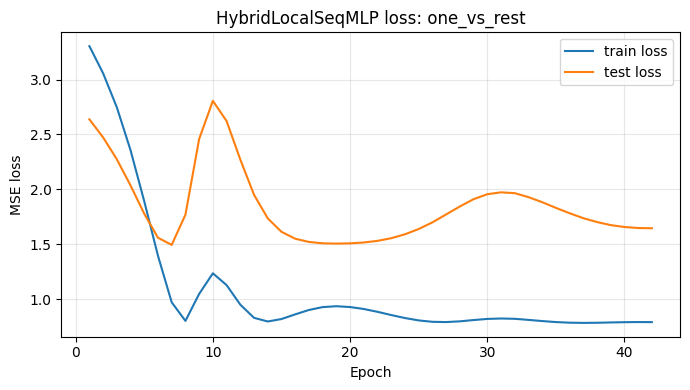

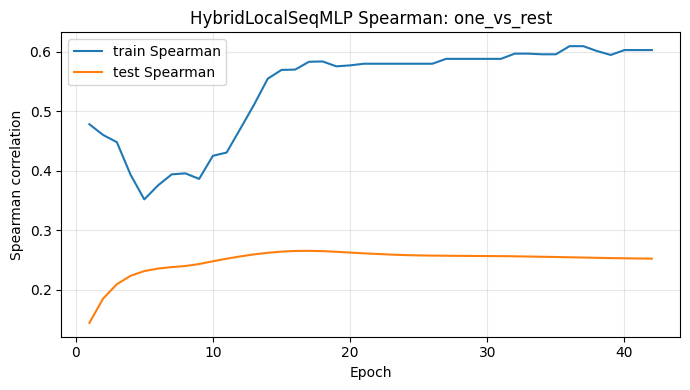


=== two_vs_rest ===


Training two_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 001 | train loss 1.0064 | test loss 1.5166 | test spearman 0.2117
epoch 010 | train loss 0.9394 | test loss 1.5288 | test spearman 0.3485
epoch 020 | train loss 0.7552 | test loss 1.3659 | test spearman 0.4338
epoch 030 | train loss 0.6988 | test loss 1.2670 | test spearman 0.4645
epoch 040 | train loss 0.5223 | test loss 1.3806 | test spearman 0.4859
epoch 050 | train loss 0.3724 | test loss 1.3007 | test spearman 0.5281
epoch 060 | train loss 0.2511 | test loss 1.3386 | test spearman 0.4682
epoch 070 | train loss 0.3096 | test loss 1.3104 | test spearman 0.5307
Early stopping at epoch 76; best epoch was 51.


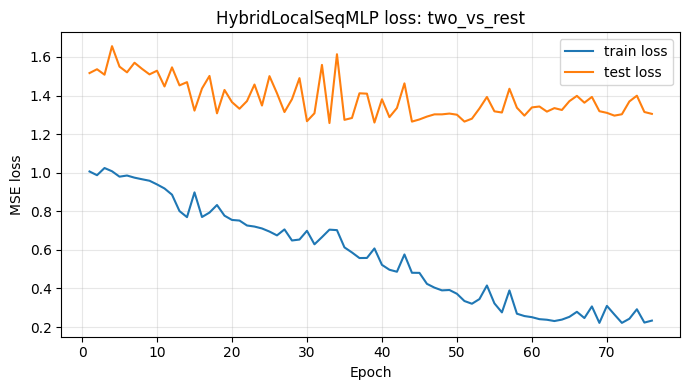

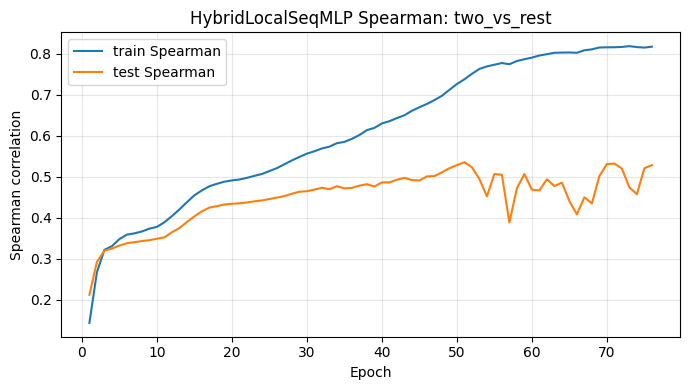


=== three_vs_rest ===


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 001 | train loss 1.1856 | test loss 1.6443 | test spearman 0.5191
epoch 010 | train loss 0.6020 | test loss 0.8616 | test spearman 0.7736
epoch 020 | train loss 0.4017 | test loss 0.7118 | test spearman 0.8169
epoch 030 | train loss 0.2936 | test loss 0.6730 | test spearman 0.8438
epoch 040 | train loss 0.2690 | test loss 0.6561 | test spearman 0.8412
epoch 050 | train loss 0.1849 | test loss 0.5236 | test spearman 0.8451
epoch 060 | train loss 0.1661 | test loss 0.4809 | test spearman 0.8479
epoch 070 | train loss 0.1479 | test loss 0.5030 | test spearman 0.8412
epoch 080 | train loss 0.1425 | test loss 0.4949 | test spearman 0.8513
epoch 090 | train loss 0.1309 | test loss 0.4921 | test spearman 0.8484
epoch 100 | train loss 0.1209 | test loss 0.4904 | test spearman 0.8519
epoch 110 | train loss 0.1056 | test loss 0.4611 | test spearman 0.8554
epoch 120 | train loss 0.1026 | test loss 0.4839 | test spearman 0.8490
epoch 130 | train loss 0.1027 | test loss 0.4622 | test spearman

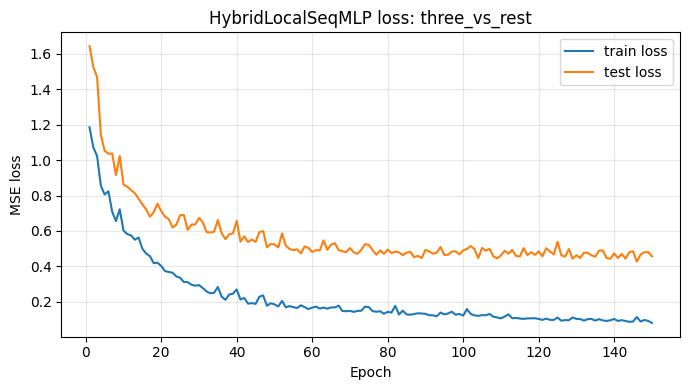

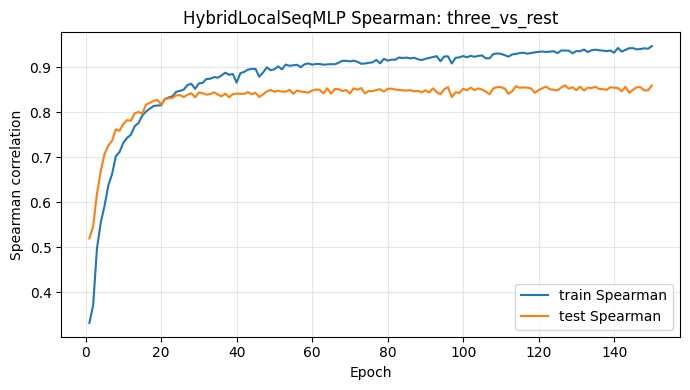

,model,split,n_train,n_test,best_epoch,best_spearman,last_spearman,best_train_loss,best_test_loss,last_train_loss,last_test_loss,best_test_mae,last_test_mae
0,HybridLocalSeqMLP,one_vs_rest,28,8705,17,0.265413,0.252298,0.902633,1.521759,0.792049,1.646342,0.989105,1.075912
1,HybridLocalSeqMLP,two_vs_rest,424,8309,51,0.535242,0.527916,0.334842,1.265061,0.233318,1.305037,0.830896,0.816116
2,HybridLocalSeqMLP,three_vs_rest,2990,5743,150,0.859240,0.859240,0.080050,0.456418,0.080050,0.456418,0.432823,0.432823


split,model,one_vs_rest,three_vs_rest,two_vs_rest
0,HybridLocalSeqMLP,0.265413,0.85924,0.535242


In [ ]:
# Train/test the simple hybrid model.
# Set RUN_ALL_SPLITS=False if you only want to test one split quickly.
RUN_ALL_SPLITS = True
SPLITS_TO_RUN = ['one_vs_rest', 'two_vs_rest', 'three_vs_rest'] if RUN_ALL_SPLITS else ['one_vs_rest']

hybrid_results = {}
summary_rows = []

for split_name in SPLITS_TO_RUN:
    print(f"\n=== {split_name} ===")
    result = train_one_hybrid_split(split_name, config=HYBRID_CONFIG, verbose=True)
    hybrid_results[split_name] = result
    summary_rows.append(result['summary'])
    plot_hybrid_history(result['history'], split_name)

hybrid_summary_df = pd.DataFrame(summary_rows)
display(hybrid_summary_df)

# Spearman values in wide format, useful for adding this model to the benchmark plots below.
hybrid_summary_wide = hybrid_summary_df.pivot_table(
    index='model',
    columns='split',
    values='best_spearman',
    aggfunc='first',
).reset_index()

display(hybrid_summary_wide)

In [ ]:
# Optional: save the hybrid training results summary and histories.
SAVE_HYBRID_RESULTS = False
HYBRID_RESULTS_DIR = BASE_DIR / 'hybrid_local_seq_results'

if SAVE_HYBRID_RESULTS:
    HYBRID_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    hybrid_summary_df.to_csv(HYBRID_RESULTS_DIR / 'hybrid_local_seq_summary.csv', index=False)
    for split_name, result in hybrid_results.items():
        result['history'].to_csv(HYBRID_RESULTS_DIR / f'hybrid_local_seq_history_{split_name}.csv', index=False)
    torch.save(
        {
            'config': HYBRID_CONFIG,
            'summary': hybrid_summary_df,
            'histories': {k: v['history'] for k, v in hybrid_results.items()},
        },
        HYBRID_RESULTS_DIR / 'hybrid_local_seq_results.pt',
    )
    print('Saved hybrid results to:', HYBRID_RESULTS_DIR)
else:
    print('Set SAVE_HYBRID_RESULTS=True to save summaries and histories.')

## Fused MLPs Hyperparameter grid

In [ ]:
ARCH_OPTIONS = [
    # baseline small/small
    {
        "arch_label": "small_global_small_local",
        "global_hidden_dims": (128, 64),
        "local_hidden_dims": (128, 64),
    },

    # main hypothesis
    {
        "arch_label": "small_global_large_local",
        "global_hidden_dims": (128, 64),
        "local_hidden_dims": (512, 256),
    },

    # control: fully large
    {
        "arch_label": "large_global_large_local",
        "global_hidden_dims": (512, 256),
        "local_hidden_dims": (512, 256),
    },
]

FUSION_OPTIONS = [
    (64,),
    (256,),
]

DROPOUT_OPTIONS = [
    0.0,
    0.1,
    0.3,
]

LOCAL_POOL_OPTIONS = [
    "mean",
    "max",
]

LR_OPTIONS = [
    1e-3,
]

In [ ]:
import itertools
from copy import deepcopy


GRID_SPLITS = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

grid_configs = []

for arch_cfg, fusion_hidden_dims, dropout, local_pool, lr in itertools.product(
    ARCH_OPTIONS,
    FUSION_OPTIONS,
    DROPOUT_OPTIONS,
    LOCAL_POOL_OPTIONS,
    LR_OPTIONS,
):
    cfg = deepcopy(HYBRID_CONFIG)

    cfg["global_hidden_dims"] = arch_cfg["global_hidden_dims"]
    cfg["local_hidden_dims"] = arch_cfg["local_hidden_dims"]
    cfg["fusion_hidden_dims"] = fusion_hidden_dims
    cfg["dropout"] = dropout
    cfg["local_pool"] = local_pool
    cfg["lr"] = lr
    cfg["batch_size"] = 128

    cfg["arch_label"] = arch_cfg["arch_label"]
    cfg["fusion_label"] = f"fusion_{fusion_hidden_dims[0]}"
    cfg["dropout_label"] = f"dropout_{dropout}"
    cfg["pool_label"] = f"pool_{local_pool}"
    cfg["lr_label"] = f"lr_{lr:g}"

    grid_configs.append(cfg)

print(f"Total grid configs: {len(grid_configs)}")

Total grid configs: 36


In [ ]:
grid_results = []
grid_histories = {}
grid_models = {}

for split_name in GRID_SPLITS:
    print("=" * 100)
    print(f"Running split: {split_name}")
    print("=" * 100)

    for i, cfg in enumerate(grid_configs):
        run_name = (
            f"{split_name}__"
            f"{cfg['arch_label']}__"
            f"{cfg['fusion_label']}__"
            f"{cfg['dropout_label']}__"
            f"{cfg['pool_label']}__"
            f"{cfg['lr_label']}"
        )

        print("\n" + "-" * 100)
        print(f"[{i + 1}/{len(grid_configs)}] {run_name}")
        print("-" * 100)

        result = train_one_hybrid_split(
            split_name=split_name,
            config=cfg,
            verbose=False,
        )

        summary = result["summary"].copy()

        summary["run_name"] = run_name
        summary["split"] = split_name
        summary["arch_label"] = cfg["arch_label"]
        summary["global_hidden_dims"] = str(cfg["global_hidden_dims"])
        summary["local_hidden_dims"] = str(cfg["local_hidden_dims"])
        summary["fusion_hidden_dims"] = str(cfg["fusion_hidden_dims"])
        summary["dropout"] = cfg["dropout"]
        summary["local_pool"] = cfg["local_pool"]
        summary["lr"] = cfg["lr"]
        summary["weight_decay"] = cfg["weight_decay"]
        summary["batch_size"] = cfg["batch_size"]

        grid_results.append(summary)
        grid_histories[run_name] = result["history"]
        grid_models[run_name] = result["model"]

grid_results_df = pd.DataFrame(grid_results)

grid_results_df = (
    grid_results_df
    .sort_values(["split", "best_spearman"], ascending=[True, False])
    .reset_index(drop=True)
)

display(grid_results_df)

Running split: one_vs_rest

----------------------------------------------------------------------------------------------------
[1/36] one_vs_rest__small_global_small_local__fusion_64__dropout_0.0__pool_mean__lr_0.001
----------------------------------------------------------------------------------------------------


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[2/36] one_vs_rest__small_global_small_local__fusion_64__dropout_0.0__pool_max__lr_0.001
----------------------------------------------------------------------------------------------------


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[3/36] one_vs_rest__small_global_small_local__fusion_64__dropout_0.1__pool_mean__lr_0.001
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
[35/36] three_vs_rest__large_global_large_local__fusion_256__dropout_0.3__pool_mean__lr_0.001
----------------------------------------------------------------------------------------------------


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[36/36] three_vs_rest__large_global_large_local__fusion_256__dropout_0.3__pool_max__lr_0.001
----------------------------------------------------------------------------------------------------


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]

,model,split,n_train,n_test,best_epoch,best_spearman,last_spearman,best_train_loss,best_test_loss,last_train_loss,...,run_name,arch_label,global_hidden_dims,local_hidden_dims,fusion_hidden_dims,dropout,local_pool,lr,weight_decay,batch_size
0,HybridLocalSeqMLP,one_vs_rest,28,8705,87,0.394075,0.370021,0.500409,1.409660,0.234441,...,one_vs_rest__small_global_small_local__fusion_...,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.001,0.0001,128
1,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.361131,0.257400,2.871882,2.360941,0.752432,...,one_vs_rest__small_global_large_local__fusion_...,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.0,max,0.001,0.0001,128
2,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.350295,0.300152,3.012883,2.446254,0.766610,...,one_vs_rest__small_global_small_local__fusion_...,small_global_small_local,"(128, 64)","(128, 64)","(256,)",0.1,max,0.001,0.0001,128
3,HybridLocalSeqMLP,one_vs_rest,28,8705,47,0.348151,0.271338,0.757696,1.482817,0.724969,...,one_vs_rest__small_global_small_local__fusion_...,small_global_small_local,"(128, 64)","(128, 64)","(256,)",0.3,max,0.001,0.0001,128
4,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.339170,0.260630,2.910694,2.380704,1.017447,...,one_vs_rest__small_global_large_local__fusion_...,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.3,max,0.001,0.0001,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,HybridLocalSeqMLP,two_vs_rest,424,8309,29,0.568472,0.542641,0.597376,1.241491,0.254985,...,two_vs_rest__small_global_large_local__fusion_...,small_global_large_local,"(128, 64)","(512, 256)","(64,)",0.3,max,0.001,0.0001,128
104,HybridLocalSeqMLP,two_vs_rest,424,8309,74,0.565074,0.539219,0.329640,1.230167,0.267817,...,two_vs_rest__large_global_large_local__fusion_...,large_global_large_local,"(512, 256)","(512, 256)","(256,)",0.3,mean,0.001,0.0001,128
105,HybridLocalSeqMLP,two_vs_rest,424,8309,63,0.562602,0.490534,0.521353,1.310970,0.235102,...,two_vs_rest__large_global_large_local__fusion_...,large_global_large_local,"(512, 256)","(512, 256)","(256,)",0.0,mean,0.001,0.0001,128
106,HybridLocalSeqMLP,two_vs_rest,424,8309,63,0.560537,0.526073,0.405606,1.268489,0.239926,...,two_vs_rest__large_global_large_local__fusion_...,large_global_large_local,"(512, 256)","(512, 256)","(256,)",0.1,mean,0.001,0.0001,128


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Make split-independent config name
# ----------------------------

plot_df = grid_results_df.copy()

# Remove leading split name from run_name
for split in ["one_vs_rest", "two_vs_rest", "three_vs_rest"]:
    plot_df["config_name"] = plot_df.get("config_name", plot_df["run_name"])
    plot_df["config_name"] = plot_df["config_name"].str.replace(
        f"^{split}__",
        "",
        regex=True
    )

# Optional: shorter labels
plot_df["config_short"] = (
    plot_df["arch_label"].astype(str)
    + " | fus=" + plot_df["fusion_hidden_dims"].astype(str)
    + " | drop=" + plot_df["dropout"].astype(str)
    + " | pool=" + plot_df["local_pool"].astype(str)
    + " | lr=" + plot_df["lr"].astype(str)
)

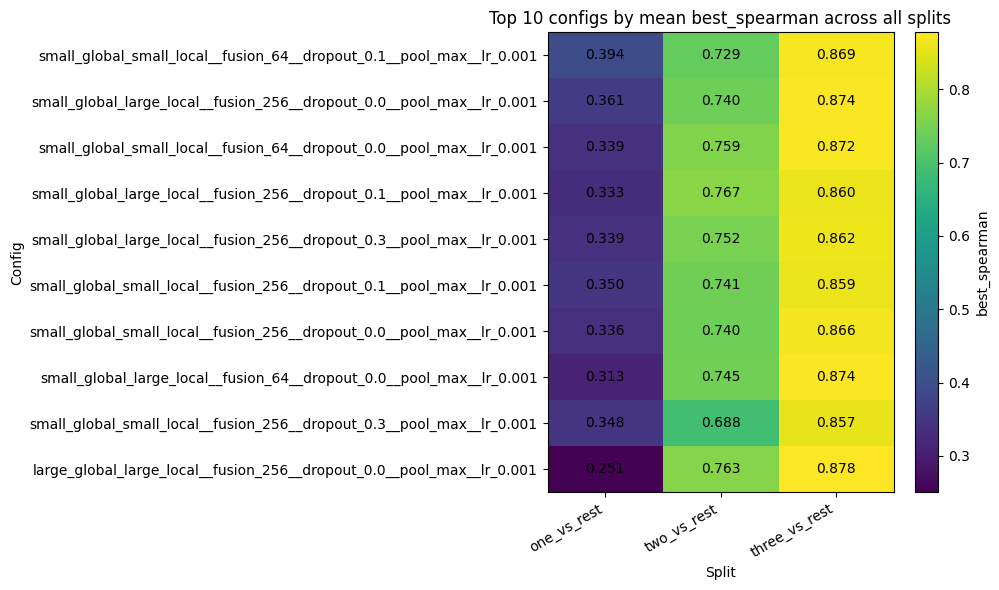

,config_name,mean_best_spearman,std_best_spearman,n_splits,config_short
32,small_global_small_local__fusion_64__dropout_0...,0.663941,0.243864,3,"small_global_small_local | fus=(64,) | drop=0...."
12,small_global_large_local__fusion_256__dropout_...,0.658390,0.266045,3,"small_global_large_local | fus=(256,) | drop=0..."
30,small_global_small_local__fusion_64__dropout_0...,0.656683,0.280867,3,"small_global_small_local | fus=(64,) | drop=0...."
14,small_global_large_local__fusion_256__dropout_...,0.653184,0.281377,3,"small_global_large_local | fus=(256,) | drop=0..."
16,small_global_large_local__fusion_256__dropout_...,0.651015,0.275667,3,"small_global_large_local | fus=(256,) | drop=0..."
26,small_global_small_local__fusion_256__dropout_...,0.650127,0.266251,3,"small_global_small_local | fus=(256,) | drop=0..."
24,small_global_small_local__fusion_256__dropout_...,0.647097,0.276996,3,"small_global_small_local | fus=(256,) | drop=0..."
18,small_global_large_local__fusion_64__dropout_0...,0.643959,0.293404,3,"small_global_large_local | fus=(64,) | drop=0...."
28,small_global_small_local__fusion_256__dropout_...,0.630847,0.259032,3,"small_global_small_local | fus=(256,) | drop=0..."
0,large_global_large_local__fusion_256__dropout_...,0.630205,0.333778,3,"large_global_large_local | fus=(256,) | drop=0..."


In [ ]:
TOP_N = 10
METRIC = "best_spearman"

# Rank configs by mean across splits
config_rank_all = (
    plot_df
    .groupby("config_name")
    .agg(
        mean_best_spearman=(METRIC, "mean"),
        std_best_spearman=(METRIC, "std"),
        n_splits=("split", "nunique"),
        config_short=("config_short", "first"),
    )
    .reset_index()
    .sort_values("mean_best_spearman", ascending=False)
)

top_configs_all = config_rank_all.head(TOP_N)["config_name"].tolist()

heatmap_all = (
    plot_df[plot_df["config_name"].isin(top_configs_all)]
    .pivot_table(
        index="config_name",
        columns="split",
        values=METRIC,
        aggfunc="mean",
    )
)

# Preserve ranking order
heatmap_all = heatmap_all.loc[top_configs_all]

# Optional: consistent split column order
split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
heatmap_all = heatmap_all[[c for c in split_order if c in heatmap_all.columns]]

plt.figure(figsize=(10, 6))
plt.imshow(heatmap_all.values, aspect="auto")
plt.colorbar(label=METRIC)

plt.xticks(
    ticks=range(len(heatmap_all.columns)),
    labels=heatmap_all.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=range(len(heatmap_all.index)),
    labels=heatmap_all.index,
)

plt.title(f"Top {TOP_N} configs by mean {METRIC} across all splits")
plt.xlabel("Split")
plt.ylabel("Config")

# Add numbers
for i in range(heatmap_all.shape[0]):
    for j in range(heatmap_all.shape[1]):
        value = heatmap_all.iloc[i, j]
        plt.text(j, i, f"{value:.3f}", ha="center", va="center")

plt.tight_layout()
plt.show()

config_rank_all.head(TOP_N)

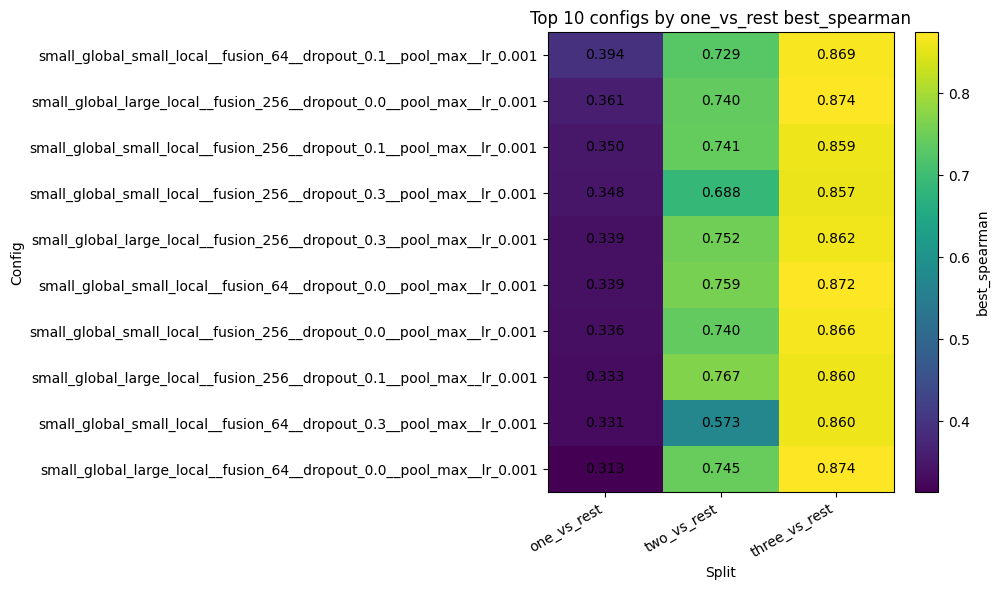

,config_name,one_vs_rest_best_spearman,config_short
32,small_global_small_local__fusion_64__dropout_0...,0.394075,"small_global_small_local | fus=(64,) | drop=0...."
12,small_global_large_local__fusion_256__dropout_...,0.361131,"small_global_large_local | fus=(256,) | drop=0..."
26,small_global_small_local__fusion_256__dropout_...,0.350295,"small_global_small_local | fus=(256,) | drop=0..."
28,small_global_small_local__fusion_256__dropout_...,0.348151,"small_global_small_local | fus=(256,) | drop=0..."
16,small_global_large_local__fusion_256__dropout_...,0.339170,"small_global_large_local | fus=(256,) | drop=0..."
30,small_global_small_local__fusion_64__dropout_0...,0.339103,"small_global_small_local | fus=(64,) | drop=0...."
24,small_global_small_local__fusion_256__dropout_...,0.335554,"small_global_small_local | fus=(256,) | drop=0..."
14,small_global_large_local__fusion_256__dropout_...,0.332752,"small_global_large_local | fus=(256,) | drop=0..."
34,small_global_small_local__fusion_64__dropout_0...,0.330656,"small_global_small_local | fus=(64,) | drop=0...."
18,small_global_large_local__fusion_64__dropout_0...,0.313439,"small_global_large_local | fus=(64,) | drop=0...."


In [ ]:
TOP_N = 10
METRIC = "best_spearman"

one_vs_rest_rank = (
    plot_df[plot_df["split"] == "one_vs_rest"]
    .groupby("config_name")
    .agg(
        one_vs_rest_best_spearman=(METRIC, "mean"),
        config_short=("config_short", "first"),
    )
    .reset_index()
    .sort_values("one_vs_rest_best_spearman", ascending=False)
)

top_configs_one = one_vs_rest_rank.head(TOP_N)["config_name"].tolist()

heatmap_one = (
    plot_df[plot_df["config_name"].isin(top_configs_one)]
    .pivot_table(
        index="config_name",
        columns="split",
        values=METRIC,
        aggfunc="mean",
    )
)

# Preserve one_vs_rest ranking order
heatmap_one = heatmap_one.loc[top_configs_one]

heatmap_one = heatmap_one[[c for c in split_order if c in heatmap_one.columns]]

plt.figure(figsize=(10, 6))
plt.imshow(heatmap_one.values, aspect="auto")
plt.colorbar(label=METRIC)

plt.xticks(
    ticks=range(len(heatmap_one.columns)),
    labels=heatmap_one.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=range(len(heatmap_one.index)),
    labels=heatmap_one.index,
)

plt.title(f"Top {TOP_N} configs by one_vs_rest {METRIC}")
plt.xlabel("Split")
plt.ylabel("Config")

for i in range(heatmap_one.shape[0]):
    for j in range(heatmap_one.shape[1]):
        value = heatmap_one.iloc[i, j]
        plt.text(j, i, f"{value:.3f}", ha="center", va="center")

plt.tight_layout()
plt.show()

one_vs_rest_rank.head(TOP_N)

## second fused MLP hyperparameter grid

In [ ]:
import itertools
import pandas as pd
from copy import deepcopy

# ----------------------------
# Second-pass grid:
# LR + weight decay with smaller architecture subset
# ----------------------------

SECOND_GRID_GLOBAL_HIDDEN_DIMS = (128, 64)

SECOND_GRID_LOCAL_OPTIONS = [
    {
        "local_label": "small_local",
        "local_hidden_dims": (128, 64),
    },
    {
        "local_label": "large_local",
        "local_hidden_dims": (512, 256),
    },
]

SECOND_GRID_FUSION_OPTIONS = [
    (64,),
    (256,),
]

SECOND_GRID_LR_OPTIONS = [
    1e-2,
    1e-3,
    1e-4,
]

SECOND_GRID_WEIGHT_DECAY_OPTIONS = [
    0.0,
    1e-4,
    1e-3,
]

SECOND_GRID_DROPOUT = 0.1
SECOND_GRID_LOCAL_POOL = "max"
SECOND_GRID_BATCH_SIZE = 128

SECOND_GRID_SPLITS = [
    "one_vs_rest",
    "two_vs_rest",
    "three_vs_rest",
]

second_grid_configs = []

for local_cfg, fusion_hidden_dims, lr, weight_decay in itertools.product(
    SECOND_GRID_LOCAL_OPTIONS,
    SECOND_GRID_FUSION_OPTIONS,
    SECOND_GRID_LR_OPTIONS,
    SECOND_GRID_WEIGHT_DECAY_OPTIONS,
):
    cfg = deepcopy(HYBRID_CONFIG)

    cfg["global_hidden_dims"] = SECOND_GRID_GLOBAL_HIDDEN_DIMS
    cfg["local_hidden_dims"] = local_cfg["local_hidden_dims"]
    cfg["fusion_hidden_dims"] = fusion_hidden_dims
    cfg["dropout"] = SECOND_GRID_DROPOUT
    cfg["local_pool"] = SECOND_GRID_LOCAL_POOL
    cfg["lr"] = lr
    cfg["weight_decay"] = weight_decay
    cfg["batch_size"] = SECOND_GRID_BATCH_SIZE

    cfg["arch_label"] = f"small_global_{local_cfg['local_label']}"
    cfg["fusion_label"] = f"fusion_{fusion_hidden_dims[0]}"
    cfg["dropout_label"] = f"dropout_{SECOND_GRID_DROPOUT}"
    cfg["pool_label"] = f"pool_{SECOND_GRID_LOCAL_POOL}"
    cfg["lr_label"] = f"lr_{lr:g}"
    cfg["wd_label"] = f"wd_{weight_decay:g}"

    second_grid_configs.append(cfg)

print(f"Total second grid configs per split: {len(second_grid_configs)}")
print(f"Total second grid runs: {len(second_grid_configs) * len(SECOND_GRID_SPLITS)}")

Total second grid configs per split: 36
Total second grid runs: 108


In [ ]:
second_grid_results = []
second_grid_histories = {}
second_grid_models = {}

for split_name in SECOND_GRID_SPLITS:
    print("=" * 100)
    print(f"Running split: {split_name}")
    print("=" * 100)

    for i, cfg in enumerate(second_grid_configs):
        run_name = (
            f"{split_name}__"
            f"{cfg['arch_label']}__"
            f"{cfg['fusion_label']}__"
            f"{cfg['dropout_label']}__"
            f"{cfg['pool_label']}__"
            f"{cfg['lr_label']}__"
            f"{cfg['wd_label']}"
        )

        print("\n" + "-" * 100)
        print(f"[{i + 1}/{len(second_grid_configs)}] {run_name}")
        print("-" * 100)

        result = train_one_hybrid_split(
            split_name=split_name,
            config=cfg,
            verbose=False,
        )

        summary = result["summary"].copy()

        summary["run_name"] = run_name
        summary["split"] = split_name
        summary["grid_stage"] = "second_lr_wd"
        summary["arch_label"] = cfg["arch_label"]
        summary["global_hidden_dims"] = str(cfg["global_hidden_dims"])
        summary["local_hidden_dims"] = str(cfg["local_hidden_dims"])
        summary["fusion_hidden_dims"] = str(cfg["fusion_hidden_dims"])
        summary["dropout"] = cfg["dropout"]
        summary["local_pool"] = cfg["local_pool"]
        summary["lr"] = cfg["lr"]
        summary["weight_decay"] = cfg["weight_decay"]
        summary["batch_size"] = cfg["batch_size"]

        second_grid_results.append(summary)
        second_grid_histories[run_name] = result["history"]
        second_grid_models[run_name] = result["model"]

second_grid_results_df = pd.DataFrame(second_grid_results)

second_grid_results_df = (
    second_grid_results_df
    .sort_values(["split", "best_spearman"], ascending=[True, False])
    .reset_index(drop=True)
)

display(second_grid_results_df)

Running split: one_vs_rest

----------------------------------------------------------------------------------------------------
[1/36] one_vs_rest__small_global_small_local__fusion_64__dropout_0.1__pool_max__lr_0.01__wd_0
----------------------------------------------------------------------------------------------------


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[2/36] one_vs_rest__small_global_small_local__fusion_64__dropout_0.1__pool_max__lr_0.01__wd_0.0001
----------------------------------------------------------------------------------------------------


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[3/36] one_vs_rest__small_global_small_local__fusion_64__dropout_0.1__pool_max__lr_0.01__wd_0.001
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
[35/36] three_vs_rest__small_global_large_local__fusion_256__dropout_0.1__pool_max__lr_0.0001__wd_0.0001
----------------------------------------------------------------------------------------------------


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[36/36] three_vs_rest__small_global_large_local__fusion_256__dropout_0.1__pool_max__lr_0.0001__wd_0.001
----------------------------------------------------------------------------------------------------


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]

,model,split,n_train,n_test,best_epoch,best_spearman,last_spearman,best_train_loss,best_test_loss,last_train_loss,...,grid_stage,arch_label,global_hidden_dims,local_hidden_dims,fusion_hidden_dims,dropout,local_pool,lr,weight_decay,batch_size
0,HybridLocalSeqMLP,one_vs_rest,28,8705,88,0.395044,0.366379,0.491725,1.405841,0.233462,...,second_lr_wd,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.0010,0.0010,128
1,HybridLocalSeqMLP,one_vs_rest,28,8705,87,0.394075,0.370021,0.500409,1.409660,0.234441,...,second_lr_wd,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.0010,0.0001,128
2,HybridLocalSeqMLP,one_vs_rest,28,8705,87,0.394073,0.369981,0.500407,1.409660,0.234454,...,second_lr_wd,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.0010,0.0000,128
3,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.352390,0.303419,3.261241,2.608734,1.593277,...,second_lr_wd,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.1,max,0.0001,0.0010,128
4,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.352390,0.303419,3.261241,2.608734,1.593264,...,second_lr_wd,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.1,max,0.0001,0.0000,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,HybridLocalSeqMLP,two_vs_rest,424,8309,1,0.267206,0.227982,1.000867,1.513099,0.923561,...,second_lr_wd,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.1,max,0.0100,0.0001,128
104,HybridLocalSeqMLP,two_vs_rest,424,8309,1,0.267106,0.226511,1.000821,1.512971,0.737695,...,second_lr_wd,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.1,max,0.0100,0.0010,128
105,HybridLocalSeqMLP,two_vs_rest,424,8309,5,0.194411,0.193202,2.293239,2.356489,0.984350,...,second_lr_wd,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.0001,0.0010,128
106,HybridLocalSeqMLP,two_vs_rest,424,8309,5,0.194411,0.193203,2.293236,2.356487,0.984349,...,second_lr_wd,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.0001,0.0000,128


In [ ]:
SECOND_GRID_RESULTS_PATH = BASE_DIR / "hybrid_local_sequence_grid_results_lr_weight_decay.csv"

second_grid_results_df.to_csv(SECOND_GRID_RESULTS_PATH, index=False)

print("Saved second grid results to:", SECOND_GRID_RESULTS_PATH)

Saved second grid results to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/hybrid_local_sequence_grid_results_lr_weight_decay.csv


In [ ]:
# Make split-independent config name
plot_df = second_grid_results_df.copy()

for split in ["one_vs_rest", "two_vs_rest", "three_vs_rest"]:
    plot_df["config_name"] = plot_df.get("config_name", plot_df["run_name"])
    plot_df["config_name"] = plot_df["config_name"].str.replace(
        f"^{split}__",
        "",
        regex=True,
    )

second_grid_rank_all = (
    plot_df
    .groupby("config_name")
    .agg(
        mean_best_spearman=("best_spearman", "mean"),
        std_best_spearman=("best_spearman", "std"),
        min_best_spearman=("best_spearman", "min"),
        max_best_spearman=("best_spearman", "max"),
        mean_best_test_loss=("best_test_loss", "mean"),
        n_splits=("split", "nunique"),
        arch_label=("arch_label", "first"),
        local_hidden_dims=("local_hidden_dims", "first"),
        fusion_hidden_dims=("fusion_hidden_dims", "first"),
        lr=("lr", "first"),
        weight_decay=("weight_decay", "first"),
        dropout=("dropout", "first"),
        local_pool=("local_pool", "first"),
    )
    .reset_index()
    .sort_values("mean_best_spearman", ascending=False)
)

second_grid_rank_all.head(20)

,config_name,mean_best_spearman,std_best_spearman,min_best_spearman,max_best_spearman,mean_best_test_loss,n_splits,arch_label,local_hidden_dims,fusion_hidden_dims,lr,weight_decay,dropout,local_pool
30,small_global_small_local__fusion_64__dropout_0...,0.664843,0.244540,0.394073,0.869603,0.963232,3,small_global_small_local,"(128, 64)","(64,)",0.0010,0.0000,0.1,max
32,small_global_small_local__fusion_64__dropout_0...,0.664715,0.243596,0.395044,0.868811,0.934059,3,small_global_small_local,"(128, 64)","(64,)",0.0010,0.0010,0.1,max
31,small_global_small_local__fusion_64__dropout_0...,0.663941,0.243864,0.394075,0.868507,0.982563,3,small_global_small_local,"(128, 64)","(64,)",0.0010,0.0001,0.1,max
3,small_global_large_local__fusion_256__dropout_...,0.657342,0.284912,0.332752,0.866067,1.212487,3,small_global_large_local,"(512, 256)","(256,)",0.0010,0.0000,0.1,max
5,small_global_large_local__fusion_256__dropout_...,0.654558,0.282746,0.332752,0.863169,1.238128,3,small_global_large_local,"(512, 256)","(256,)",0.0010,0.0010,0.1,max
4,small_global_large_local__fusion_256__dropout_...,0.653184,0.281377,0.332752,0.859937,1.218793,3,small_global_large_local,"(512, 256)","(256,)",0.0010,0.0001,0.1,max
23,small_global_small_local__fusion_256__dropout_...,0.653111,0.267951,0.350295,0.859517,1.272919,3,small_global_small_local,"(128, 64)","(256,)",0.0010,0.0010,0.1,max
22,small_global_small_local__fusion_256__dropout_...,0.650127,0.266251,0.350295,0.858910,1.285195,3,small_global_small_local,"(128, 64)","(256,)",0.0010,0.0001,0.1,max
21,small_global_small_local__fusion_256__dropout_...,0.649081,0.266419,0.350295,0.861909,1.281050,3,small_global_small_local,"(128, 64)","(256,)",0.0010,0.0000,0.1,max
12,small_global_large_local__fusion_64__dropout_0...,0.634768,0.294837,0.303029,0.866902,0.922038,3,small_global_large_local,"(512, 256)","(64,)",0.0010,0.0000,0.1,max


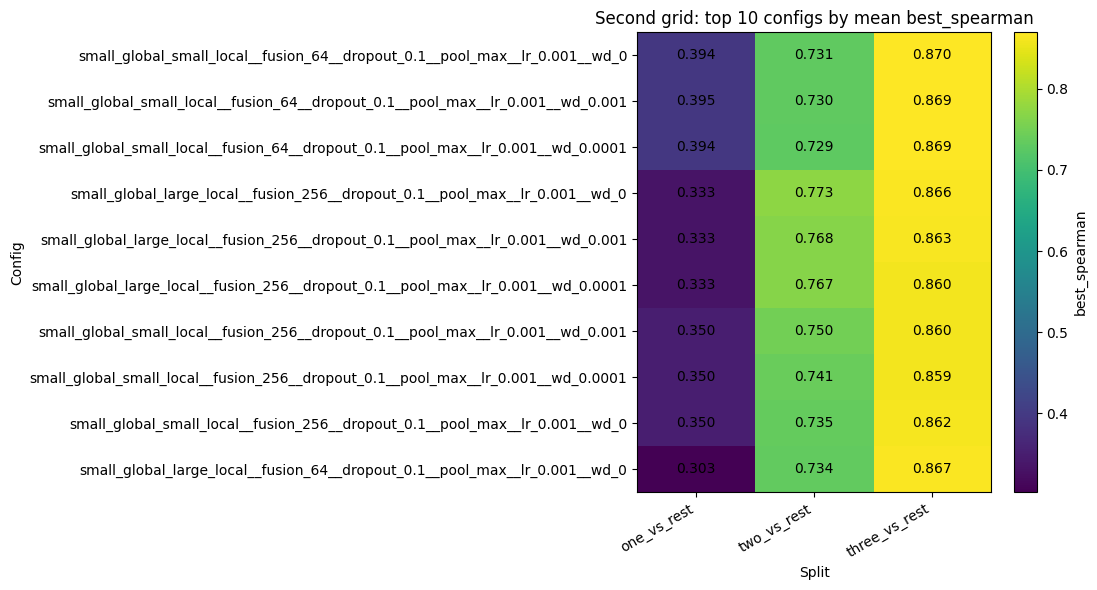

In [ ]:
import matplotlib.pyplot as plt

TOP_N = 10
METRIC = "best_spearman"

top_configs = second_grid_rank_all.head(TOP_N)["config_name"].tolist()

heatmap_df = (
    plot_df[plot_df["config_name"].isin(top_configs)]
    .pivot_table(
        index="config_name",
        columns="split",
        values=METRIC,
        aggfunc="mean",
    )
)

heatmap_df = heatmap_df.loc[top_configs]

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
heatmap_df = heatmap_df[[c for c in split_order if c in heatmap_df.columns]]

plt.figure(figsize=(11, 6))
plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label=METRIC)

plt.xticks(
    ticks=range(len(heatmap_df.columns)),
    labels=heatmap_df.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=range(len(heatmap_df.index)),
    labels=heatmap_df.index,
)

plt.title(f"Second grid: top {TOP_N} configs by mean {METRIC}")
plt.xlabel("Split")
plt.ylabel("Config")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        plt.text(j, i, f"{value:.3f}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
1e-2

0.01

## MLP FUsion grid 3 - final refinement

In [ ]:
import itertools
import pandas as pd
from copy import deepcopy

# ----------------------------
# Third-pass focused architecture grid:
# global size + local size + fusion size
# fixed lr / wd / dropout / pool
# ----------------------------

FOCUSED_GRID_GLOBAL_OPTIONS = [
    {
        "global_label": "xsmall_global",
        "global_hidden_dims": (64, 32),
    },
    {
        "global_label": "small_global",
        "global_hidden_dims": (128, 64),
    },
]

FOCUSED_GRID_LOCAL_OPTIONS = [
    {
        "local_label": "small_local",
        "local_hidden_dims": (128, 64),
    },
    {
        "local_label": "medium_local",
        "local_hidden_dims": (256, 128),
    },
    {
        "local_label": "large_local",
        "local_hidden_dims": (512, 256),
    },
]

FOCUSED_GRID_FUSION_OPTIONS = [
    (64,),
    (128,),
    (256,),
]

FOCUSED_GRID_LR = 1e-3
FOCUSED_GRID_WEIGHT_DECAY = 1e-3
FOCUSED_GRID_DROPOUT = 0.1
FOCUSED_GRID_LOCAL_POOL = "max"
FOCUSED_GRID_BATCH_SIZE = 128

FOCUSED_GRID_SPLITS = [
    "one_vs_rest",
    "two_vs_rest",
    "three_vs_rest",
]

focused_grid_configs = []

for global_cfg, local_cfg, fusion_hidden_dims in itertools.product(
    FOCUSED_GRID_GLOBAL_OPTIONS,
    FOCUSED_GRID_LOCAL_OPTIONS,
    FOCUSED_GRID_FUSION_OPTIONS,
):
    cfg = deepcopy(HYBRID_CONFIG)

    cfg["global_hidden_dims"] = global_cfg["global_hidden_dims"]
    cfg["local_hidden_dims"] = local_cfg["local_hidden_dims"]
    cfg["fusion_hidden_dims"] = fusion_hidden_dims
    cfg["dropout"] = FOCUSED_GRID_DROPOUT
    cfg["local_pool"] = FOCUSED_GRID_LOCAL_POOL
    cfg["lr"] = FOCUSED_GRID_LR
    cfg["weight_decay"] = FOCUSED_GRID_WEIGHT_DECAY
    cfg["batch_size"] = FOCUSED_GRID_BATCH_SIZE

    cfg["arch_label"] = f"{global_cfg['global_label']}_{local_cfg['local_label']}"
    cfg["global_label"] = global_cfg["global_label"]
    cfg["local_label"] = local_cfg["local_label"]
    cfg["fusion_label"] = f"fusion_{fusion_hidden_dims[0]}"
    cfg["dropout_label"] = f"dropout_{FOCUSED_GRID_DROPOUT}"
    cfg["pool_label"] = f"pool_{FOCUSED_GRID_LOCAL_POOL}"
    cfg["lr_label"] = f"lr_{FOCUSED_GRID_LR:g}"
    cfg["wd_label"] = f"wd_{FOCUSED_GRID_WEIGHT_DECAY:g}"

    focused_grid_configs.append(cfg)

print(f"Total focused grid configs per split: {len(focused_grid_configs)}")
print(f"Total focused grid runs: {len(focused_grid_configs) * len(FOCUSED_GRID_SPLITS)}")

Total focused grid configs per split: 18
Total focused grid runs: 54


In [ ]:
focused_grid_results = []
focused_grid_histories = {}
focused_grid_models = {}

for split_name in FOCUSED_GRID_SPLITS:
    print("=" * 100)
    print(f"Running split: {split_name}")
    print("=" * 100)

    for i, cfg in enumerate(focused_grid_configs):
        run_name = (
            f"{split_name}__"
            f"{cfg['arch_label']}__"
            f"{cfg['fusion_label']}__"
            f"{cfg['dropout_label']}__"
            f"{cfg['pool_label']}__"
            f"{cfg['lr_label']}__"
            f"{cfg['wd_label']}"
        )

        print("\n" + "-" * 100)
        print(f"[{i + 1}/{len(focused_grid_configs)}] {run_name}")
        print("-" * 100)

        result = train_one_hybrid_split(
            split_name=split_name,
            config=cfg,
            verbose=False,
        )

        summary = result["summary"].copy()

        summary["run_name"] = run_name
        summary["split"] = split_name
        summary["grid_stage"] = "focused_global_local_fusion"
        summary["arch_label"] = cfg["arch_label"]
        summary["global_label"] = cfg["global_label"]
        summary["local_label"] = cfg["local_label"]
        summary["global_hidden_dims"] = str(cfg["global_hidden_dims"])
        summary["local_hidden_dims"] = str(cfg["local_hidden_dims"])
        summary["fusion_hidden_dims"] = str(cfg["fusion_hidden_dims"])
        summary["dropout"] = cfg["dropout"]
        summary["local_pool"] = cfg["local_pool"]
        summary["lr"] = cfg["lr"]
        summary["weight_decay"] = cfg["weight_decay"]
        summary["batch_size"] = cfg["batch_size"]

        focused_grid_results.append(summary)
        focused_grid_histories[run_name] = result["history"]
        focused_grid_models[run_name] = result["model"]

focused_grid_results_df = pd.DataFrame(focused_grid_results)

focused_grid_results_df = (
    focused_grid_results_df
    .sort_values(["split", "best_spearman"], ascending=[True, False])
    .reset_index(drop=True)
)

display(focused_grid_results_df)

Running split: one_vs_rest

----------------------------------------------------------------------------------------------------
[1/18] one_vs_rest__xsmall_global_small_local__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[2/18] one_vs_rest__xsmall_global_small_local__fusion_128__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------


Training one_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[3/18] one_vs_rest__xsmall_global_small_local__fusion_256__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
[17/18] three_vs_rest__small_global_large_local__fusion_128__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
[18/18] three_vs_rest__small_global_large_local__fusion_256__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------


Training three_vs_rest:   0%|          | 0/150 [00:00<?, ?it/s]

,model,split,n_train,n_test,best_epoch,best_spearman,last_spearman,best_train_loss,best_test_loss,last_train_loss,...,global_label,local_label,global_hidden_dims,local_hidden_dims,fusion_hidden_dims,dropout,local_pool,lr,weight_decay,batch_size
0,HybridLocalSeqMLP,one_vs_rest,28,8705,88,0.395044,0.366379,0.491725,1.405841,0.233462,...,small_global,small_local,"(128, 64)","(128, 64)","(64,)",0.1,max,0.001,0.001,128
1,HybridLocalSeqMLP,one_vs_rest,28,8705,10,0.367710,0.237760,0.914480,1.492755,0.692285,...,xsmall_global,large_local,"(64, 32)","(512, 256)","(256,)",0.1,max,0.001,0.001,128
2,HybridLocalSeqMLP,one_vs_rest,28,8705,17,0.362635,0.331054,0.870978,1.510216,0.715725,...,small_global,medium_local,"(128, 64)","(256, 128)","(64,)",0.1,max,0.001,0.001,128
3,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.361199,0.309424,3.172028,2.551990,0.788638,...,small_global,small_local,"(128, 64)","(128, 64)","(128,)",0.1,max,0.001,0.001,128
4,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.353878,0.256271,3.495798,2.770640,0.934590,...,xsmall_global,small_local,"(64, 32)","(128, 64)","(64,)",0.1,max,0.001,0.001,128
5,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.350295,0.300147,3.012884,2.446255,0.766610,...,small_global,small_local,"(128, 64)","(128, 64)","(256,)",0.1,max,0.001,0.001,128
6,HybridLocalSeqMLP,one_vs_rest,28,8705,15,0.342188,0.247770,0.885366,1.473916,0.642859,...,small_global,medium_local,"(128, 64)","(256, 128)","(128,)",0.1,max,0.001,0.001,128
7,HybridLocalSeqMLP,one_vs_rest,28,8705,1,0.332752,0.264913,2.874623,2.361188,0.804524,...,small_global,large_local,"(128, 64)","(512, 256)","(256,)",0.1,max,0.001,0.001,128
8,HybridLocalSeqMLP,one_vs_rest,28,8705,19,0.317382,0.231021,0.900420,1.498104,0.766333,...,xsmall_global,small_local,"(64, 32)","(128, 64)","(256,)",0.1,max,0.001,0.001,128
9,HybridLocalSeqMLP,one_vs_rest,28,8705,11,0.311670,0.270550,0.850768,1.876607,0.762676,...,small_global,medium_local,"(128, 64)","(256, 128)","(256,)",0.1,max,0.001,0.001,128


In [ ]:
FOCUSED_GRID_RESULTS_PATH = BASE_DIR / "hybrid_local_sequence_grid_results_focused_global_local_fusion.csv"

focused_grid_results_df.to_csv(FOCUSED_GRID_RESULTS_PATH, index=False)

print("Saved focused grid results to:", FOCUSED_GRID_RESULTS_PATH)

Saved focused grid results to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/hybrid_local_sequence_grid_results_focused_global_local_fusion.csv


In [ ]:
focused_plot_df = focused_grid_results_df.copy()

for split in ["one_vs_rest", "two_vs_rest", "three_vs_rest"]:
    focused_plot_df["config_name"] = focused_plot_df.get("config_name", focused_plot_df["run_name"])
    focused_plot_df["config_name"] = focused_plot_df["config_name"].str.replace(
        f"^{split}__",
        "",
        regex=True,
    )

focused_grid_rank_all = (
    focused_plot_df
    .groupby("config_name")
    .agg(
        mean_best_spearman=("best_spearman", "mean"),
        std_best_spearman=("best_spearman", "std"),
        min_best_spearman=("best_spearman", "min"),
        max_best_spearman=("best_spearman", "max"),
        mean_last_spearman=("last_spearman", "mean"),
        mean_best_test_loss=("best_test_loss", "mean"),
        n_splits=("split", "nunique"),
        global_label=("global_label", "first"),
        local_label=("local_label", "first"),
        arch_label=("arch_label", "first"),
        global_hidden_dims=("global_hidden_dims", "first"),
        local_hidden_dims=("local_hidden_dims", "first"),
        fusion_hidden_dims=("fusion_hidden_dims", "first"),
        lr=("lr", "first"),
        weight_decay=("weight_decay", "first"),
        dropout=("dropout", "first"),
        local_pool=("local_pool", "first"),
    )
    .reset_index()
    .sort_values("mean_best_spearman", ascending=False)
)

focused_grid_rank_all.head(20)

,config_name,mean_best_spearman,std_best_spearman,min_best_spearman,max_best_spearman,mean_last_spearman,mean_best_test_loss,n_splits,global_label,local_label,arch_label,global_hidden_dims,local_hidden_dims,fusion_hidden_dims,lr,weight_decay,dropout,local_pool
8,small_global_small_local__fusion_64__dropout_0...,0.664715,0.243596,0.395044,0.868811,0.651045,0.934059,3,small_global,small_local,small_global_small_local,"(128, 64)","(128, 64)","(64,)",0.001,0.001,0.1,max
5,small_global_medium_local__fusion_64__dropout_...,0.663458,0.266834,0.362635,0.871568,0.647827,0.937218,3,small_global,medium_local,small_global_medium_local,"(128, 64)","(256, 128)","(64,)",0.001,0.001,0.1,max
10,xsmall_global_large_local__fusion_256__dropout...,0.660812,0.259495,0.367710,0.861275,0.610514,0.933062,3,xsmall_global,large_local,xsmall_global_large_local,"(64, 32)","(512, 256)","(256,)",0.001,0.001,0.1,max
3,small_global_medium_local__fusion_128__dropout...,0.660055,0.279254,0.342188,0.865927,0.623331,0.906630,3,small_global,medium_local,small_global_medium_local,"(128, 64)","(256, 128)","(128,)",0.001,0.001,0.1,max
1,small_global_large_local__fusion_256__dropout_...,0.654558,0.282746,0.332752,0.863169,0.627399,1.238128,3,small_global,large_local,small_global_large_local,"(128, 64)","(512, 256)","(256,)",0.001,0.001,0.1,max
6,small_global_small_local__fusion_128__dropout_...,0.653243,0.260870,0.361199,0.863185,0.629286,1.303840,3,small_global,small_local,small_global_small_local,"(128, 64)","(128, 64)","(128,)",0.001,0.001,0.1,max
7,small_global_small_local__fusion_256__dropout_...,0.653111,0.267951,0.350295,0.859517,0.631096,1.272919,3,small_global,small_local,small_global_small_local,"(128, 64)","(128, 64)","(256,)",0.001,0.001,0.1,max
4,small_global_medium_local__fusion_256__dropout...,0.642511,0.293121,0.311670,0.869806,0.623271,1.093901,3,small_global,medium_local,small_global_medium_local,"(128, 64)","(256, 128)","(256,)",0.001,0.001,0.1,max
16,xsmall_global_small_local__fusion_256__dropout...,0.640619,0.285270,0.317382,0.857171,0.607654,0.960494,3,xsmall_global,small_local,xsmall_global_small_local,"(64, 32)","(128, 64)","(256,)",0.001,0.001,0.1,max
0,small_global_large_local__fusion_128__dropout_...,0.640402,0.310080,0.286540,0.864617,0.617013,1.254139,3,small_global,large_local,small_global_large_local,"(128, 64)","(512, 256)","(128,)",0.001,0.001,0.1,max


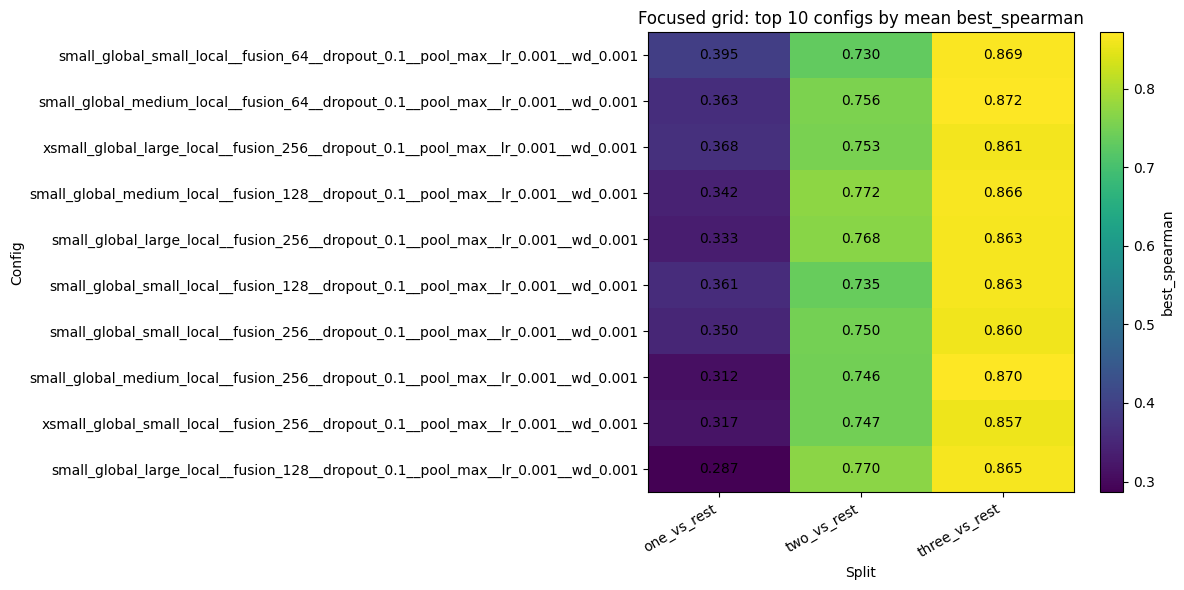

In [ ]:
import matplotlib.pyplot as plt

TOP_N = 10
METRIC = "best_spearman"

top_configs = focused_grid_rank_all.head(TOP_N)["config_name"].tolist()

focused_heatmap_df = (
    focused_plot_df[focused_plot_df["config_name"].isin(top_configs)]
    .pivot_table(
        index="config_name",
        columns="split",
        values=METRIC,
        aggfunc="mean",
    )
)

focused_heatmap_df = focused_heatmap_df.loc[top_configs]

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
focused_heatmap_df = focused_heatmap_df[[c for c in split_order if c in focused_heatmap_df.columns]]

plt.figure(figsize=(12, 6))
plt.imshow(focused_heatmap_df.values, aspect="auto")
plt.colorbar(label=METRIC)

plt.xticks(
    ticks=range(len(focused_heatmap_df.columns)),
    labels=focused_heatmap_df.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=range(len(focused_heatmap_df.index)),
    labels=focused_heatmap_df.index,
)

plt.title(f"Focused grid: top {TOP_N} configs by mean {METRIC}")
plt.xlabel("Split")
plt.ylabel("Config")

for i in range(focused_heatmap_df.shape[0]):
    for j in range(focused_heatmap_df.shape[1]):
        value = focused_heatmap_df.iloc[i, j]
        plt.text(j, i, f"{value:.3f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## Local as CNN Grid 1

In [13]:
import torch
import torch.nn as nn


class HybridGB1CNNLocalModel(nn.Module):
    """
    Hybrid GB1 model with:
      - global MLP branch over X_seq_mean
      - local 1D CNN branch over X_window_k5 / local sequence
      - fusion MLP head

    This is intended to be a drop-in replacement for HybridGB1LocalSequenceModel:
      - x_mean / x_seq_mean: (batch, embed_dim)
      - x_window / x_local: (batch, local_len, embed_dim)
    """

    def __init__(
        self,
        embed_dim: int,
        local_len: int,
        global_hidden_dims=(128, 64),
        cnn_channels=128,
        cnn_kernel_size=3,
        cnn_num_layers=1,
        fusion_hidden_dims=(64,),
        dropout: float = 0.1,
        activation: str = "gelu",
        local_pool: str = "max",
    ):
        super().__init__()

        if len(global_hidden_dims) == 0 or len(fusion_hidden_dims) == 0:
            raise ValueError("global_hidden_dims and fusion_hidden_dims must be non-empty.")
        if cnn_kernel_size % 2 == 0:
            raise ValueError("Use an odd cnn_kernel_size so padding preserves local_len cleanly.")
        if local_pool not in {"max", "mean"}:
            raise ValueError("local_pool must be either 'max' or 'mean'.")

        self.embed_dim = embed_dim
        self.local_len = local_len
        self.local_pool = local_pool

        self.global_branch = self._make_mlp(
            input_dim=embed_dim,
            hidden_dims=global_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        self.local_cnn = self._make_cnn(
            input_channels=embed_dim,
            hidden_channels=cnn_channels,
            kernel_size=cnn_kernel_size,
            num_layers=cnn_num_layers,
            dropout=dropout,
            activation=activation,
        )

        fusion_input_dim = global_hidden_dims[-1] + cnn_channels

        self.fusion_head = self._make_mlp(
            input_dim=fusion_input_dim,
            hidden_dims=fusion_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        self.output_layer = nn.Linear(fusion_hidden_dims[-1], 1)

    def _get_activation(self, activation: str):
        activation = activation.lower()
        if activation == "relu":
            return nn.ReLU()
        if activation == "gelu":
            return nn.GELU()
        if activation == "silu":
            return nn.SiLU()
        raise ValueError(f"Unknown activation: {activation}")

    def _make_mlp(self, input_dim, hidden_dims, dropout, activation):
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self._get_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        return nn.Sequential(*layers)

    def _make_cnn(
        self,
        input_channels,
        hidden_channels,
        kernel_size,
        num_layers,
        dropout,
        activation,
    ):
        layers = []
        padding = kernel_size // 2
        in_channels = input_channels

        for _ in range(num_layers):
            layers.append(
                nn.Conv1d(
                    in_channels=in_channels,
                    out_channels=hidden_channels,
                    kernel_size=kernel_size,
                    padding=padding,
                )
            )
            layers.append(self._get_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_channels = hidden_channels

        return nn.Sequential(*layers)

    def forward(self, x_seq_mean=None, x_local=None, x_mean=None, x_window=None):
        """
        Accept both naming conventions so this model works with the existing
        evaluate_hybrid_model(), which calls model(x_mean=..., x_window=...).
        """
        if x_seq_mean is None:
            x_seq_mean = x_mean
        if x_local is None:
            x_local = x_window

        if x_seq_mean is None or x_local is None:
            raise ValueError("Provide x_seq_mean/x_local or x_mean/x_window.")
        if x_seq_mean.ndim != 2:
            raise ValueError(f"x_seq_mean should have shape (batch, embed_dim), got {tuple(x_seq_mean.shape)}")
        if x_local.ndim != 3:
            raise ValueError(f"x_local should have shape (batch, local_len, embed_dim), got {tuple(x_local.shape)}")
        if x_local.shape[1] != self.local_len or x_local.shape[2] != self.embed_dim:
            raise ValueError(
                f"Expected x_local shape (*, {self.local_len}, {self.embed_dim}), got {tuple(x_local.shape)}"
            )

        global_repr = self.global_branch(x_seq_mean)

        # Conv1d expects (batch, channels, sequence_length), so embedding dim is channels.
        x_local_cnn = x_local.transpose(1, 2)
        local_token_repr = self.local_cnn(x_local_cnn)

        if self.local_pool == "max":
            local_repr = local_token_repr.max(dim=-1).values
        elif self.local_pool == "mean":
            local_repr = local_token_repr.mean(dim=-1)
        else:
            raise ValueError(f"Unknown local_pool: {self.local_pool}")

        combined = torch.cat([global_repr, local_repr], dim=-1)
        hidden = self.fusion_head(combined)
        return self.output_layer(hidden).squeeze(-1)


In [14]:
def train_one_hybrid_cnn_split(
    split_name,
    config,
    verbose=True,
):
    """
    Train the CNN-local hybrid model using the same split_tensors_hybrid,
    loaders, and evaluator as the MLP-local hybrid model.

    This avoids three bugs from the earlier CNN draft:
      1. relying on split_indices being defined in a later cell,
      2. passing TensorDataset tuple batches into evaluate_hybrid_model(), which expects dict batches,
      3. calling evaluate_hybrid_model(data_loader=...), although the function argument is named loader.
    """
    set_seed(config.get("seed", 42))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, test_loader = make_hybrid_loaders(
        split_tensors_hybrid,
        split_name=split_name,
        batch_size=config["batch_size"],
        test_batch_size=config.get("test_batch_size", 512),
    )

    embed_dim = split_tensors_hybrid[split_name]["X_mean_train"].shape[-1]
    local_len = split_tensors_hybrid[split_name]["X_window_train"].shape[1]

    model = HybridGB1CNNLocalModel(
        embed_dim=embed_dim,
        local_len=local_len,
        global_hidden_dims=config["global_hidden_dims"],
        cnn_channels=config["cnn_channels"],
        cnn_kernel_size=config["cnn_kernel_size"],
        cnn_num_layers=config["cnn_num_layers"],
        fusion_hidden_dims=config["fusion_hidden_dims"],
        dropout=config["dropout"],
        activation=config.get("activation", "gelu"),
        local_pool=config.get("local_pool", "max"),
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    loss_fn = nn.MSELoss()
    history = []

    best_spearman = -float("inf")
    best_epoch = None
    best_summary = None
    best_state_dict = None
    epochs_without_improvement = 0

    max_epochs = config.get("max_epochs", 150)
    patience = config.get("patience", 25)

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for batch in train_loader:
            x_mean = batch["mean"].to(device)
            x_window = batch["window"].to(device)
            y = batch["y"].to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x_mean=x_mean, x_window=x_window)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * y.numel()
            train_n += y.numel()

        train_eval, _, _ = evaluate_hybrid_model(
            model=model,
            loader=train_loader,
            device=device,
        )

        test_eval, _, _ = evaluate_hybrid_model(
            model=model,
            loader=test_loader,
            device=device,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss_sum / max(train_n, 1),
            "train_eval_loss": train_eval["loss"],
            "test_loss": test_eval["loss"],
            "train_spearman": train_eval["spearman"],
            "test_spearman": test_eval["spearman"],
            "train_mae": train_eval["mae"],
            "test_mae": test_eval["mae"],
        }
        history.append(row)

        if verbose and ((epoch == 1) or (epoch % 10 == 0)):
            print(
                f"epoch {epoch:03d} | "
                f"train loss {row['train_eval_loss']:.4f} | "
                f"test loss {row['test_loss']:.4f} | "
                f"test spearman {row['test_spearman']:.4f}"
            )

        if test_eval["spearman"] > best_spearman:
            best_spearman = test_eval["spearman"]
            best_epoch = epoch
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_summary = {
                "model": "HybridLocalCNN",
                "split": split_name,
                "n_train": int(split_tensors_hybrid[split_name]["y_train"].numel()),
                "n_test": int(split_tensors_hybrid[split_name]["y_test"].numel()),
                "best_epoch": int(best_epoch),
                "best_spearman": float(test_eval["spearman"]),
                "best_train_loss": float(train_eval["loss"]),
                "best_test_loss": float(test_eval["loss"]),
                "best_train_mae": float(train_eval["mae"]),
                "best_test_mae": float(test_eval["mae"]),
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    history_df = pd.DataFrame(history)
    last_row = history_df.iloc[-1]

    summary = best_summary.copy()
    summary.update(
        {
            "last_epoch": int(last_row["epoch"]),
            "last_spearman": float(last_row["test_spearman"]),
            "last_train_loss": float(last_row["train_eval_loss"]),
            "last_test_loss": float(last_row["test_loss"]),
            "last_train_mae": float(last_row["train_mae"]),
            "last_test_mae": float(last_row["test_mae"]),
        }
    )

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    _, y_test_np, pred_test_np = evaluate_hybrid_model(
        model=model,
        loader=test_loader,
        device=device,
    )

    return {
        "summary": summary,
        "history": history_df,
        "model": model,
        "config": dict(config),
        "y_test": y_test_np,
        "pred_test": pred_test_np,
    }


In [15]:
import numpy as np

split_indices = {}

for split_name in ["one_vs_rest", "two_vs_rest", "three_vs_rest"]:
    train_idx = np.where(df_full[split_name].values == "train")[0]
    test_idx = np.where(df_full[split_name].values == "test")[0]

    split_indices[split_name] = {
        "train_idx": train_idx,
        "test_idx": test_idx,
    }

split_indices

{'one_vs_rest': {'train_idx': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
         17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]),
  'test_idx': array([  28,   29,   30, ..., 8730, 8731, 8732])},
 'two_vs_rest': {'train_idx': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
          13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
          26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
          39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
          52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
          65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
          78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
          91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
         104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
         117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       

In [18]:
# Manually define best hybrid config after kernel restart
# This matches: small global, small local, fusion_64, dropout 0.1, pool max, lr 0.001, wd 0.001

best_hybrid_config = {
    "name": "manual_best_hybrid__small_global__small_local__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001",

    # Architecture
    "global_hidden": [128],
    "local_hidden": [128],
    "fusion_hidden": [64],
    "dropout": 0.1,
    "pool": "max",

    # Training
    "lr": 1e-3,
    "weight_decay": 1e-3,
}

In [19]:
import itertools
import pandas as pd
from copy import deepcopy

CNN_BASE_CONFIG = deepcopy(best_hybrid_config)

CNN_BASE_CONFIG["global_hidden_dims"] = (128, 64)
CNN_BASE_CONFIG["fusion_hidden_dims"] = (64,)
CNN_BASE_CONFIG["dropout"] = 0.1
CNN_BASE_CONFIG["local_pool"] = "max"
CNN_BASE_CONFIG["lr"] = 1e-3
CNN_BASE_CONFIG["weight_decay"] = 1e-3
CNN_BASE_CONFIG["batch_size"] = 128

CNN_CHANNEL_OPTIONS = [
    64,
    128,
    256,
]

CNN_KERNEL_OPTIONS = [
    3,
    5,
]

CNN_NUM_LAYER_OPTIONS = [
    1,
    2,
]

CNN_GRID_SPLITS = [
    "one_vs_rest",
    "two_vs_rest",
    "three_vs_rest",
]

cnn_grid_configs = []

for cnn_channels, cnn_kernel_size, cnn_num_layers in itertools.product(
    CNN_CHANNEL_OPTIONS,
    CNN_KERNEL_OPTIONS,
    CNN_NUM_LAYER_OPTIONS,
):
    cfg = deepcopy(CNN_BASE_CONFIG)

    cfg["cnn_channels"] = cnn_channels
    cfg["cnn_kernel_size"] = cnn_kernel_size
    cfg["cnn_num_layers"] = cnn_num_layers

    cfg["arch_label"] = "cnn_local"
    cfg["global_label"] = "small_global"
    cfg["fusion_label"] = "fusion_64"
    cfg["dropout_label"] = "dropout_0.1"
    cfg["pool_label"] = "pool_max"
    cfg["lr_label"] = "lr_0.001"
    cfg["wd_label"] = "wd_0.001"
    cfg["cnn_label"] = (
        f"cnn_ch{cnn_channels}_k{cnn_kernel_size}_layers{cnn_num_layers}"
    )

    cnn_grid_configs.append(cfg)

print(f"Total CNN configs per split: {len(cnn_grid_configs)}")
print(f"Total CNN runs: {len(cnn_grid_configs) * len(CNN_GRID_SPLITS)}")

Total CNN configs per split: 12
Total CNN runs: 36


In [23]:
# Quick CNN smoke test before launching the full grid.
# This checks tensor shapes, batch format, forward pass, and one tiny training run.
CNN_SMOKE_TEST = True

if CNN_SMOKE_TEST:
    smoke_cfg = deepcopy(CNN_BASE_CONFIG)
    smoke_cfg.update({
        "cnn_channels": 32,
        "cnn_kernel_size": 3,
        "cnn_num_layers": 1,
        "max_epochs": 2,
        "patience": 2,
    })

    smoke_result = train_one_hybrid_cnn_split(
        split_name="one_vs_rest",
        config=smoke_cfg,
        verbose=True,
    )

    display(pd.DataFrame([smoke_result["summary"]]))


epoch 001 | train loss 3.1511 | test loss 2.5509 | test spearman 0.1282


,model,split,n_train,n_test,best_epoch,best_spearman,best_train_loss,best_test_loss,best_train_mae,best_test_mae,last_epoch,last_spearman,last_train_loss,last_test_loss,last_train_mae,last_test_mae
0,HybridLocalCNN,one_vs_rest,28,8705,2,0.158945,2.736826,2.295504,1.389632,1.031152,2,0.158945,2.736826,2.295504,1.389632,1.031152


In [24]:
cnn_grid_results = []
cnn_grid_histories = {}
cnn_grid_models = {}

for split_name in CNN_GRID_SPLITS:
    print("=" * 100)
    print(f"Running split: {split_name}")
    print("=" * 100)

    for i, cfg in enumerate(cnn_grid_configs):
        run_name = (
            f"{split_name}__"
            f"{cfg['arch_label']}__"
            f"{cfg['cnn_label']}__"
            f"{cfg['fusion_label']}__"
            f"{cfg['dropout_label']}__"
            f"{cfg['pool_label']}__"
            f"{cfg['lr_label']}__"
            f"{cfg['wd_label']}"
        )

        print("\n" + "-" * 100)
        print(f"[{i + 1}/{len(cnn_grid_configs)}] {run_name}")
        print("-" * 100)

        result = train_one_hybrid_cnn_split(
            split_name=split_name,
            config=cfg,
            verbose=False,
        )

        summary = result["summary"].copy()

        summary["run_name"] = run_name
        summary["split"] = split_name
        summary["grid_stage"] = "cnn_local_branch"
        summary["arch_label"] = cfg["arch_label"]
        summary["global_hidden_dims"] = str(cfg["global_hidden_dims"])
        summary["fusion_hidden_dims"] = str(cfg["fusion_hidden_dims"])
        summary["dropout"] = cfg["dropout"]
        summary["local_pool"] = cfg["local_pool"]
        summary["lr"] = cfg["lr"]
        summary["weight_decay"] = cfg["weight_decay"]
        summary["batch_size"] = cfg["batch_size"]
        summary["cnn_channels"] = cfg["cnn_channels"]
        summary["cnn_kernel_size"] = cfg["cnn_kernel_size"]
        summary["cnn_num_layers"] = cfg["cnn_num_layers"]

        cnn_grid_results.append(summary)
        cnn_grid_histories[run_name] = result["history"]
        cnn_grid_models[run_name] = result["model"]

cnn_grid_results_df = pd.DataFrame(cnn_grid_results)

cnn_grid_results_df = (
    cnn_grid_results_df
    .sort_values(["split", "best_spearman"], ascending=[True, False])
    .reset_index(drop=True)
)

display(cnn_grid_results_df)

Running split: one_vs_rest

----------------------------------------------------------------------------------------------------
[1/12] one_vs_rest__cnn_local__cnn_ch64_k3_layers1__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
[2/12] one_vs_rest__cnn_local__cnn_ch64_k3_layers2__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
[3/12] one_vs_rest__cnn_local__cnn_ch64_k5_layers1__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------

------------------------------------------------

,model,split,n_train,n_test,best_epoch,best_spearman,best_train_loss,best_test_loss,best_train_mae,best_test_mae,...,global_hidden_dims,fusion_hidden_dims,dropout,local_pool,lr,weight_decay,batch_size,cnn_channels,cnn_kernel_size,cnn_num_layers
0,HybridLocalCNN,one_vs_rest,28,8705,7,0.377261,1.199267,1.512682,0.742882,0.895966,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,256,5,2
1,HybridLocalCNN,one_vs_rest,28,8705,8,0.370308,1.046005,1.476411,0.688759,0.920003,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,128,5,2
2,HybridLocalCNN,one_vs_rest,28,8705,24,0.347551,0.729944,1.587966,0.647793,1.050153,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,64,5,2
3,HybridLocalCNN,one_vs_rest,28,8705,13,0.341700,0.764500,1.742379,0.695522,1.130865,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,256,3,2
4,HybridLocalCNN,one_vs_rest,28,8705,5,0.339190,0.866362,1.485867,0.659427,0.962006,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,256,5,1
5,HybridLocalCNN,one_vs_rest,28,8705,26,0.336299,0.764850,1.750698,0.692966,1.133810,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,64,3,2
6,HybridLocalCNN,one_vs_rest,28,8705,7,0.329193,0.830419,1.499088,0.655853,0.979188,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,256,3,1
7,HybridLocalCNN,one_vs_rest,28,8705,16,0.306959,0.740747,1.710639,0.689025,1.116765,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,128,5,1
8,HybridLocalCNN,one_vs_rest,28,8705,46,0.297478,0.614094,1.492644,0.600892,0.990479,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,128,3,2
9,HybridLocalCNN,one_vs_rest,28,8705,21,0.280302,0.769082,1.775041,0.707001,1.144451,...,"(128, 64)","(64,)",0.1,max,0.001,0.001,128,128,3,1


Using hyperparameter columns:
['cnn_channels', 'cnn_kernel_size', 'cnn_num_layers', 'fusion_hidden_dims', 'dropout', 'lr', 'weight_decay']

Columns containing 'layer':
['cnn_num_layers']

Number of splits found per config:


,count
split,
3,12


/tmp/ipykernel_10020/796392274.py:168: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


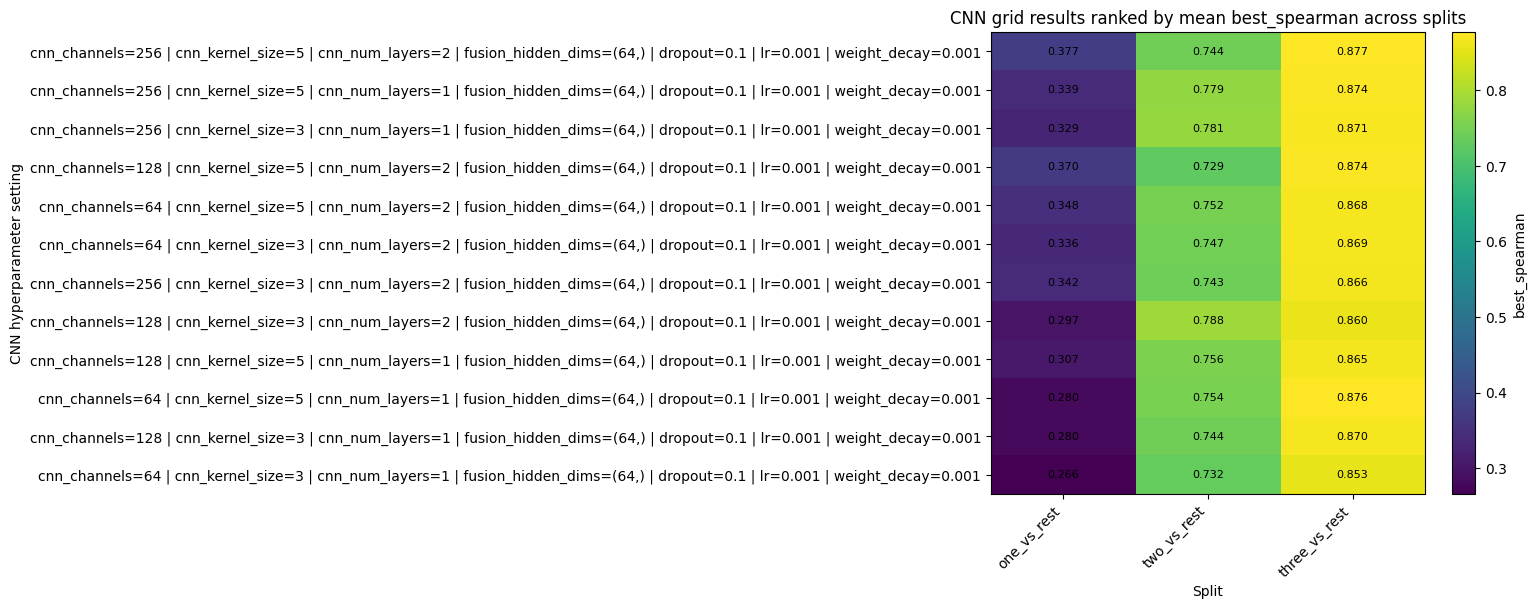

split,one_vs_rest,two_vs_rest,three_vs_rest
config_label,,,
"cnn_channels=256 | cnn_kernel_size=5 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.377261,0.743773,0.876986
"cnn_channels=256 | cnn_kernel_size=5 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.339190,0.779058,0.874440
"cnn_channels=256 | cnn_kernel_size=3 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.329193,0.780501,0.870532
"cnn_channels=128 | cnn_kernel_size=5 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.370308,0.728677,0.874049
"cnn_channels=64 | cnn_kernel_size=5 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.347551,0.752097,0.868496
"cnn_channels=64 | cnn_kernel_size=3 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.336299,0.747223,0.869008
"cnn_channels=256 | cnn_kernel_size=3 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.341700,0.742761,0.865574
"cnn_channels=128 | cnn_kernel_size=3 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.297478,0.788483,0.859592
"cnn_channels=128 | cnn_kernel_size=5 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | lr=0.001 | weight_decay=0.001",0.306959,0.756086,0.865359


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Build ranked heatmap table: one row per hyperparameter setting
# ---------------------------------------------------------------------

df = cnn_grid_results_df.copy()

metric_col = "best_spearman"

if metric_col not in df.columns:
    raise ValueError(
        f"Could not find {metric_col}. Available columns are:\n{df.columns.tolist()}"
    )

# Identify split column
possible_split_cols = ["split", "split_name"]

split_col = None
for col in possible_split_cols:
    if col in df.columns:
        split_col = col
        break

if split_col is None:
    raise ValueError(
        f"Could not find split column. Available columns are:\n{df.columns.tolist()}"
    )

# ---------------------------------------------------------------------
# Hyperparameter columns that define one CNN setting.
# Added several possible "layers" column names so layer count is not dropped.
# ---------------------------------------------------------------------

candidate_hparam_cols = [
    "cnn_channels",
    "cnn_ch",
    "channels",

    "cnn_kernel_size",
    "kernel_size",
    "cnn_k",
    "k",

    "cnn_layers",
    "cnn_num_layers",
    "num_cnn_layers",
    "n_cnn_layers",
    "n_layers",
    "layers",

    "fusion_hidden",
    "fusion_hidden_dim",
    "fusion_hidden_dims",

    "dropout",
    "pool",
    "pool_type",

    "lr",
    "learning_rate",

    "weight_decay",
    "wd",
]

hparam_cols = [c for c in candidate_hparam_cols if c in df.columns]

if not hparam_cols:
    raise ValueError(
        "Could not find hyperparameter columns to group by. "
        f"Available columns are:\n{df.columns.tolist()}"
    )

print("Using hyperparameter columns:")
print(hparam_cols)

# Optional diagnostic: show columns that may contain layer info
print("\nColumns containing 'layer':")
print([c for c in df.columns if "layer" in c.lower()])

# Make a compact readable label for each hyperparameter setting
def make_config_label(row):
    return " | ".join([f"{c}={row[c]}" for c in hparam_cols])

df["config_label"] = df.apply(make_config_label, axis=1)

# Sanity check: each config should ideally have one row per split
counts = (
    df.groupby("config_label")[split_col]
    .nunique()
    .sort_values(ascending=False)
)

print("\nNumber of splits found per config:")
display(counts.value_counts().sort_index())

# ---------------------------------------------------------------------
# Pivot to one row per config and one column per split
# ---------------------------------------------------------------------

heatmap_df = df.pivot_table(
    index="config_label",
    columns=split_col,
    values=metric_col,
    aggfunc="mean",
)

# Enforce split order
preferred_split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
existing_order = [s for s in preferred_split_order if s in heatmap_df.columns]
remaining_cols = [c for c in heatmap_df.columns if c not in existing_order]
split_metric_cols = existing_order + remaining_cols

heatmap_df = heatmap_df[split_metric_cols]

# Rank by mean across splits, but do NOT keep the mean as a plotted column
rank_mean = heatmap_df.mean(axis=1, skipna=True)
heatmap_df = heatmap_df.loc[rank_mean.sort_values(ascending=False).index]

# Optional: keep only top N configs
TOP_N = None  # e.g., 20
if TOP_N is not None:
    heatmap_df = heatmap_df.head(TOP_N)

# ---------------------------------------------------------------------
# Plot heatmap
# ---------------------------------------------------------------------

plot_df = heatmap_df.copy()

fig_height = max(6, 0.35 * len(plot_df))
fig_width = max(7, 1.5 * len(plot_df.columns))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)

ax.set_title(f"CNN grid results ranked by mean {metric_col} across splits")
ax.set_xlabel("Split")
ax.set_ylabel("CNN hyperparameter setting")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(metric_col)

# Annotate values
for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        val = plot_df.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

plt.tight_layout()
plt.show()

heatmap_df

## CNN Grid 2 - Final Refinement

In [37]:
from itertools import product
from copy import deepcopy

# ---------------------------------------------------------------------
# Second CNN grid: larger CNN capacity + larger kernels
# Start from CNN_BASE_CONFIG so required/default keys are preserved
# ---------------------------------------------------------------------

cnn_channels_grid = [256, 384, 512]
cnn_kernel_size_grid = [3, 5, 7, 9]
cnn_num_layers_grid = [1, 2, 3]

cnn_grid_2_configs = []

for cnn_channels, cnn_kernel_size, cnn_num_layers in product(
    cnn_channels_grid,
    cnn_kernel_size_grid,
    cnn_num_layers_grid,
):
    cfg = deepcopy(CNN_BASE_CONFIG)

    # Update only the CNN hyperparameters we want to sweep
    cfg["cnn_channels"] = cnn_channels
    cfg["cnn_kernel_size"] = cnn_kernel_size

    # Include both names in case different notebook cells expect different keys
    cfg["cnn_num_layers"] = cnn_num_layers
    cfg["cnn_layers"] = cnn_num_layers

    # Keep these fixed for this second grid
    cfg["fusion_hidden_dims"] = (64,)
    cfg["dropout"] = 0.1
    cfg["lr"] = 1e-3
    cfg["weight_decay"] = 1e-3
    cfg["pool"] = "max"

    cfg["name"] = (
        f"cnn_grid2__"
        f"ch{cnn_channels}__"
        f"k{cnn_kernel_size}__"
        f"layers{cnn_num_layers}__"
        f"fusion64__"
        f"dropout0.1__"
        f"lr0.001__"
        f"wd0.001"
    )

    cnn_grid_2_configs.append(cfg)

print(f"Number of CNN grid 2 configs: {len(cnn_grid_2_configs)}")
cnn_grid_2_configs[0]

Number of CNN grid 2 configs: 36


{'name': 'cnn_grid2__ch256__k3__layers1__fusion64__dropout0.1__lr0.001__wd0.001',
 'global_hidden': [128],
 'local_hidden': [128],
 'fusion_hidden': [64],
 'dropout': 0.1,
 'pool': 'max',
 'lr': 0.001,
 'weight_decay': 0.001,
 'global_hidden_dims': (128, 64),
 'fusion_hidden_dims': (64,),
 'local_pool': 'max',
 'batch_size': 128,
 'cnn_channels': 256,
 'cnn_kernel_size': 3,
 'cnn_num_layers': 1,
 'cnn_layers': 1}

In [38]:
cnn_grid_2_results = []

for split_name in ["one_vs_rest", "two_vs_rest", "three_vs_rest"]:
    print("=" * 100)
    print(f"Running split: {split_name}")
    print("=" * 100)

    for i, cfg in enumerate(cnn_grid_2_configs, start=1):
        print()
        print("-" * 100)
        print(f"[{i}/{len(cnn_grid_2_configs)}] {split_name}__{cfg['name']}")
        print("-" * 100)

        result = train_one_hybrid_cnn_split(
            split_name=split_name,
            config=cfg,
            verbose=False,
        )

        cnn_grid_2_results.append({
            "split": split_name,
            **cfg,
            **result,
        })

cnn_grid_2_results_df = pd.DataFrame(cnn_grid_2_results)
cnn_grid_2_results_df

Running split: one_vs_rest

----------------------------------------------------------------------------------------------------
[1/36] one_vs_rest__cnn_grid2__ch256__k3__layers1__fusion64__dropout0.1__lr0.001__wd0.001
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
[2/36] one_vs_rest__cnn_grid2__ch256__k3__layers2__fusion64__dropout0.1__lr0.001__wd0.001
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
[3/36] one_vs_rest__cnn_grid2__ch256__k3__layers3__fusion64__dropout0.1__lr0.001__wd0.001
----------------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------

,split,name,global_hidden,local_hidden,fusion_hidden,dropout,pool,lr,weight_decay,global_hidden_dims,...,cnn_channels,cnn_kernel_size,cnn_num_layers,cnn_layers,summary,history,model,config,y_test,pred_test
0,one_vs_rest,cnn_grid2__ch256__k3__layers1__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,256,3,1,1,"{'model': 'HybridLocalCNN', 'split': 'one_vs_r...",epoch train_loss train_eval_loss test_l...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch256__k3__layers1__fusio...,"[0.98238856, 0.600373, 0.6578, 1.7040833, 1.24...","[1.3735511, 1.3626819, 1.3685815, 1.3826115, 1..."
1,one_vs_rest,cnn_grid2__ch256__k3__layers2__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,256,3,2,2,"{'model': 'HybridLocalCNN', 'split': 'one_vs_r...",epoch train_loss train_eval_loss test_l...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch256__k3__layers2__fusio...,"[0.98238856, 0.600373, 0.6578, 1.7040833, 1.24...","[1.7804135, 1.7524511, 1.786238, 1.7881805, 1...."
2,one_vs_rest,cnn_grid2__ch256__k3__layers3__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,256,3,3,3,"{'model': 'HybridLocalCNN', 'split': 'one_vs_r...",epoch train_loss train_eval_loss test_l...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch256__k3__layers3__fusio...,"[0.98238856, 0.600373, 0.6578, 1.7040833, 1.24...","[0.16134559, 0.16131899, 0.16122231, 0.1613304..."
3,one_vs_rest,cnn_grid2__ch256__k5__layers1__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,256,5,1,1,"{'model': 'HybridLocalCNN', 'split': 'one_vs_r...",epoch train_loss train_eval_loss test_l...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch256__k5__layers1__fusio...,"[0.98238856, 0.600373, 0.6578, 1.7040833, 1.24...","[1.3188493, 1.2985919, 1.3165064, 1.3195571, 1..."
4,one_vs_rest,cnn_grid2__ch256__k5__layers2__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,256,5,2,2,"{'model': 'HybridLocalCNN', 'split': 'one_vs_r...",epoch train_loss train_eval_loss test_l...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch256__k5__layers2__fusio...,"[0.98238856, 0.600373, 0.6578, 1.7040833, 1.24...","[0.97552913, 0.9709676, 0.9768838, 0.97836584,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,three_vs_rest,cnn_grid2__ch512__k7__layers2__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,512,7,2,2,"{'model': 'HybridLocalCNN', 'split': 'three_vs...",epoch train_loss train_eval_loss test_...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch512__k7__layers2__fusio...,"[1.61161, 3.7418334, 0.0, 1.081518, 2.08725, 0...","[2.9015033, 3.0154085, -0.015741974, 1.7123606..."
104,three_vs_rest,cnn_grid2__ch512__k7__layers3__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,512,7,3,3,"{'model': 'HybridLocalCNN', 'split': 'three_vs...",epoch train_loss train_eval_loss test_...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch512__k7__layers3__fusio...,"[1.61161, 3.7418334, 0.0, 1.081518, 2.08725, 0...","[2.8595974, 2.52352, 0.007947458, 2.1130636, 2..."
105,three_vs_rest,cnn_grid2__ch512__k9__layers1__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,512,9,1,1,"{'model': 'HybridLocalCNN', 'split': 'three_vs...",epoch train_loss train_eval_loss test_...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__ch512__k9__layers1__fusio...,"[1.61161, 3.7418334, 0.0, 1.081518, 2.08725, 0...","[1.9013551, 3.2774785, -0.03500723, 1.479004, ..."
106,three_vs_rest,cnn_grid2__ch512__k9__layers2__fusion64__dropo...,[128],[128],[64],0.1,max,0.001,0.001,"(128, 64)",...,512,9,2,2,"{'model': 'HybridLocalCNN', 'split': 'three_vs...",epoch train_loss train_eval_loss test_l...,HybridGB1CNNLocalModel(\n (global_branch): Se...,{'name': 'cnn_grid2__c

In [61]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

df = cnn_grid_2_results_df.copy()

def safe_spearman(row):
    y = np.asarray(row["y_test"])
    pred = np.asarray(row["pred_test"])

    # flatten in case they are shape (n, 1)
    y = y.ravel()
    pred = pred.ravel()

    if len(y) == 0 or len(pred) == 0:
        return np.nan

    return spearmanr(y, pred).correlation

df["test_spearman"] = df.apply(safe_spearman, axis=1)

df[["split", "name", "cnn_channels", "cnn_kernel_size", "cnn_num_layers", "test_spearman"]].head()

,split,name,cnn_channels,cnn_kernel_size,cnn_num_layers,test_spearman
0,one_vs_rest,cnn_grid2__ch256__k3__layers1__fusion64__dropo...,256,3,1,0.329193
1,one_vs_rest,cnn_grid2__ch256__k3__layers2__fusion64__dropo...,256,3,2,0.341700
2,one_vs_rest,cnn_grid2__ch256__k3__layers3__fusion64__dropo...,256,3,3,0.364176
3,one_vs_rest,cnn_grid2__ch256__k5__layers1__fusion64__dropo...,256,5,1,0.339190
4,one_vs_rest,cnn_grid2__ch256__k5__layers2__fusion64__dropo...,256,5,2,0.377261


/tmp/ipykernel_10020/3005115895.py:80: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


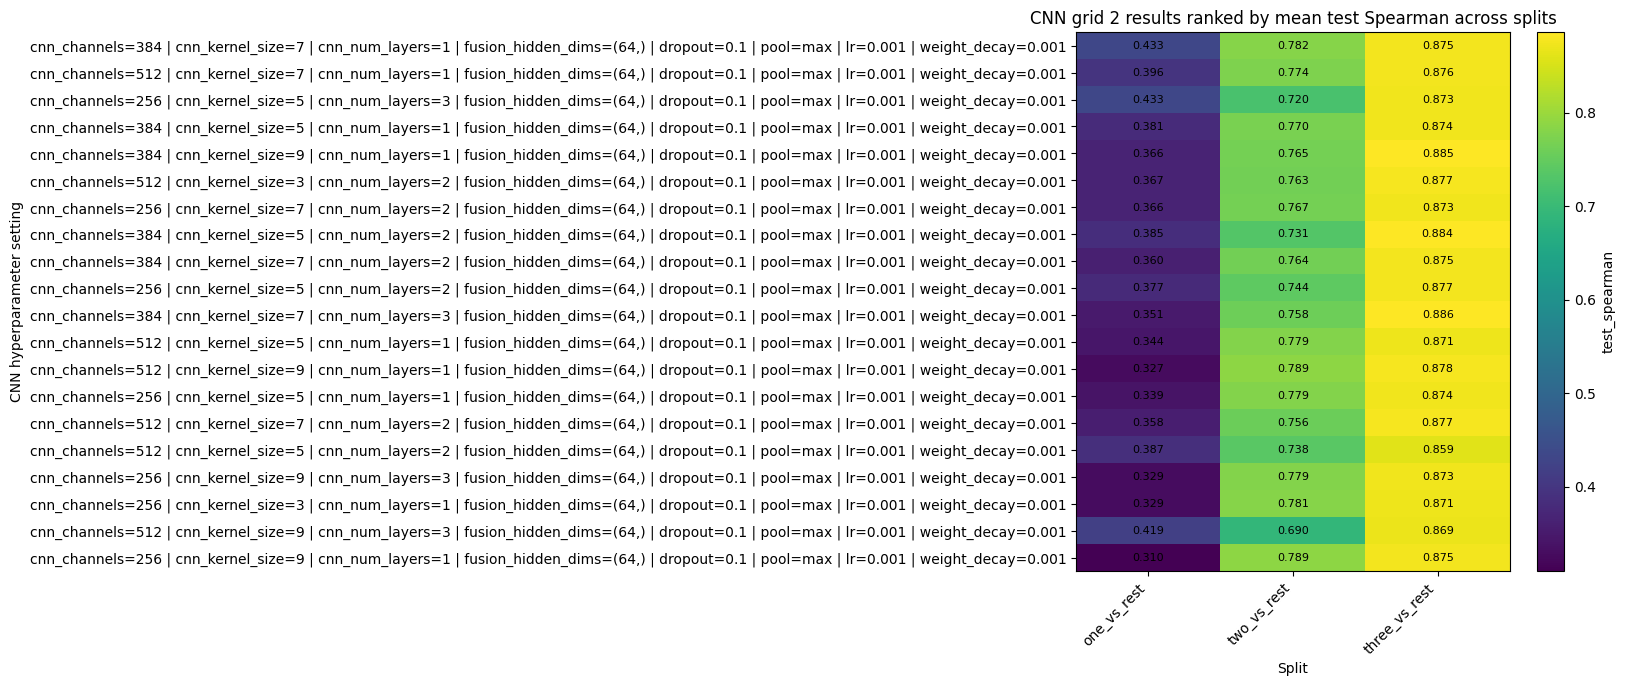

split,one_vs_rest,two_vs_rest,three_vs_rest
config_label,,,
"cnn_channels=384 | cnn_kernel_size=7 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.433264,0.781649,0.875390
"cnn_channels=512 | cnn_kernel_size=7 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.396434,0.774150,0.876283
"cnn_channels=256 | cnn_kernel_size=5 | cnn_num_layers=3 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.432812,0.719945,0.873030
"cnn_channels=384 | cnn_kernel_size=5 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.381247,0.769665,0.873810
"cnn_channels=384 | cnn_kernel_size=9 | cnn_num_layers=1 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.366006,0.765397,0.885344
"cnn_channels=512 | cnn_kernel_size=3 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.366598,0.762583,0.877171
"cnn_channels=256 | cnn_kernel_size=7 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.366418,0.766515,0.872665
"cnn_channels=384 | cnn_kernel_size=5 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.384881,0.731233,0.884321
"cnn_channels=384 | cnn_kernel_size=7 | cnn_num_layers=2 | fusion_hidden_dims=(64,) | dropout=0.1 | pool=max | lr=0.001 | weight_decay=0.001",0.360304,0.764044,0.875287


In [42]:
import matplotlib.pyplot as plt

metric_col = "test_spearman"
split_col = "split"

# Use only true hyperparameter identity columns
hparam_cols = [
    "cnn_channels",
    "cnn_kernel_size",
    "cnn_num_layers",
    "fusion_hidden_dims",
    "dropout",
    "pool",
    "lr",
    "weight_decay",
]

hparam_cols = [c for c in hparam_cols if c in df.columns]

def make_config_label(row):
    return " | ".join([f"{c}={row[c]}" for c in hparam_cols])

df["config_label"] = df.apply(make_config_label, axis=1)

heatmap_df = df.pivot_table(
    index="config_label",
    columns=split_col,
    values=metric_col,
    aggfunc="mean",
)

preferred_split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
existing_order = [s for s in preferred_split_order if s in heatmap_df.columns]
remaining_cols = [c for c in heatmap_df.columns if c not in existing_order]
heatmap_df = heatmap_df[existing_order + remaining_cols]

# Rank by mean across splits, but do not plot the mean column
rank_mean = heatmap_df.mean(axis=1, skipna=True)
heatmap_df = heatmap_df.loc[rank_mean.sort_values(ascending=False).index]

TOP_N = 20  # set to 20 if too tall
if TOP_N is not None:
    heatmap_df = heatmap_df.head(TOP_N)

plot_df = heatmap_df.copy()

fig_height = max(6, 0.35 * len(plot_df))
fig_width = max(7, 1.7 * len(plot_df.columns))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)

ax.set_title("CNN grid 2 results ranked by mean test Spearman across splits")
ax.set_xlabel("Split")
ax.set_ylabel("CNN hyperparameter setting")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("test_spearman")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        val = plot_df.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

plt.tight_layout()
plt.show()

heatmap_df

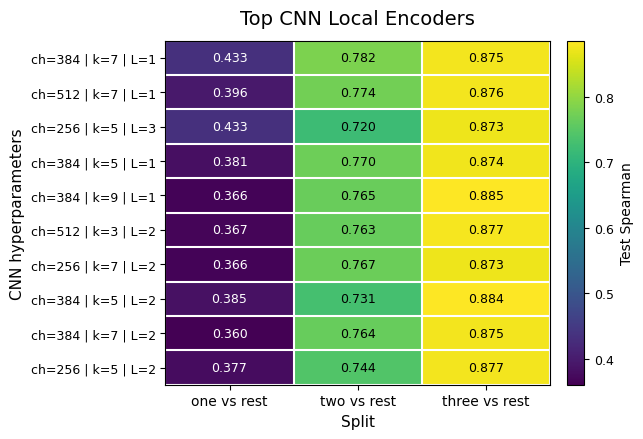

split,one_vs_rest,two_vs_rest,three_vs_rest
config_label,,,
ch=384 | k=7 | L=1,0.433264,0.781649,0.875390
ch=512 | k=7 | L=1,0.396434,0.774150,0.876283
ch=256 | k=5 | L=3,0.432812,0.719945,0.873030
ch=384 | k=5 | L=1,0.381247,0.769665,0.873810
ch=384 | k=9 | L=1,0.366006,0.765397,0.885344
ch=512 | k=3 | L=2,0.366598,0.762583,0.877171
ch=256 | k=7 | L=2,0.366418,0.766515,0.872665
ch=384 | k=5 | L=2,0.384881,0.731233,0.884321
ch=384 | k=7 | L=2,0.360304,0.764044,0.875287


In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metric_col = "test_spearman"
split_col = "split"

df_plot = df.copy()

# ---------------------------------------------------------------------
# Compact CNN-only labels
# ---------------------------------------------------------------------

required_cols = ["cnn_channels", "cnn_kernel_size", "cnn_num_layers"]
missing = [c for c in required_cols if c not in df_plot.columns]
if missing:
    raise ValueError(f"Missing required columns for compact labels: {missing}")

def make_compact_cnn_label(row):
    return (
        f"ch={row['cnn_channels']} | "
        f"k={row['cnn_kernel_size']} | "
        f"L={row['cnn_num_layers']}"
    )

df_plot["config_label"] = df_plot.apply(make_compact_cnn_label, axis=1)

# ---------------------------------------------------------------------
# Pivot to one row per CNN setting and rank by mean across splits
# ---------------------------------------------------------------------

heatmap_df = df_plot.pivot_table(
    index="config_label",
    columns=split_col,
    values=metric_col,
    aggfunc="mean",
)

preferred_split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
existing_order = [s for s in preferred_split_order if s in heatmap_df.columns]
remaining_cols = [c for c in heatmap_df.columns if c not in existing_order]
heatmap_df = heatmap_df[existing_order + remaining_cols]

rank_mean = heatmap_df.mean(axis=1, skipna=True)
heatmap_df = heatmap_df.loc[rank_mean.sort_values(ascending=False).index]

TOP_N = 10
heatmap_df = heatmap_df.head(TOP_N)

plot_df = heatmap_df.copy()

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig_height = max(4.5, 0.42 * len(plot_df))
fig_width = 6.5

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(
    [str(c).replace("_", " ") for c in plot_df.columns],
    fontsize=10,
)

ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index, fontsize=9)

ax.set_title(
    "Top CNN Local Encoders",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("CNN hyperparameters", fontsize=11)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Test Spearman", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ---------------------------------------------------------------------
# Adaptive annotation color
# ---------------------------------------------------------------------

values = plot_df.values.astype(float)
valid_values = values[~np.isnan(values)]

# Threshold at midpoint of displayed color range
text_color_threshold = valid_values.min() + 0.5 * (valid_values.max() - valid_values.min())

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        val = plot_df.iloc[i, j]
        if pd.notna(val):
            text_color = "white" if val < text_color_threshold else "black"
            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
            )

# Light cell boundaries make it easier to read
ax.set_xticks(np.arange(-0.5, plot_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_df.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

heatmap_df

## Attention Based Model

In [44]:
import torch
import torch.nn as nn
import pandas as pd
from copy import deepcopy
import itertools


class HybridGB1AttentionLocalModel(nn.Module):
    """
    Hybrid GB1 model with:
      - global MLP branch over x_mean
      - local self-attention branch over x_window
      - fusion MLP head

    Inputs
    ------
    x_mean:
        shape (batch, embed_dim)

    x_window:
        shape (batch, local_len, embed_dim)
    """

    def __init__(
        self,
        embed_dim: int,
        local_len: int,
        global_hidden_dims=(128, 64),
        attn_dim=128,
        attn_num_heads=4,
        attn_num_layers=1,
        attn_ff_dim=256,
        fusion_hidden_dims=(64,),
        dropout: float = 0.1,
        activation: str = "gelu",
        local_pool: str = "max",
    ):
        super().__init__()

        if len(global_hidden_dims) == 0 or len(fusion_hidden_dims) == 0:
            raise ValueError("global_hidden_dims and fusion_hidden_dims must be non-empty.")

        if attn_dim % attn_num_heads != 0:
            raise ValueError(
                f"attn_dim={attn_dim} must be divisible by attn_num_heads={attn_num_heads}."
            )

        if local_pool not in {"max", "mean", "cls"}:
            raise ValueError("local_pool must be one of: 'max', 'mean', 'cls'.")

        self.embed_dim = embed_dim
        self.local_len = local_len
        self.attn_dim = attn_dim
        self.local_pool = local_pool

        self.global_branch = self._make_mlp(
            input_dim=embed_dim,
            hidden_dims=global_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        # Project ESM embedding dim, e.g. 640, down to smaller attention dim.
        self.local_input_proj = nn.Linear(embed_dim, attn_dim)

        # Learned positional embeddings are important for local residue windows.
        self.pos_embedding = nn.Parameter(torch.zeros(1, local_len, attn_dim))
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

        if local_pool == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, attn_dim))
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
            encoder_len = local_len + 1
        else:
            self.cls_token = None
            encoder_len = local_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=attn_dim,
            nhead=attn_num_heads,
            dim_feedforward=attn_ff_dim,
            dropout=dropout,
            activation=activation,
            batch_first=True,
            norm_first=True,
        )

        self.local_attention = nn.TransformerEncoder(
            encoder_layer,
            num_layers=attn_num_layers,
        )

        self.local_norm = nn.LayerNorm(attn_dim)

        fusion_input_dim = global_hidden_dims[-1] + attn_dim

        self.fusion_head = self._make_mlp(
            input_dim=fusion_input_dim,
            hidden_dims=fusion_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        self.output_layer = nn.Linear(fusion_hidden_dims[-1], 1)

    def _get_activation(self, activation: str):
        activation = activation.lower()
        if activation == "relu":
            return nn.ReLU()
        if activation == "gelu":
            return nn.GELU()
        if activation == "silu":
            return nn.SiLU()
        raise ValueError(f"Unknown activation: {activation}")

    def _make_mlp(self, input_dim, hidden_dims, dropout, activation):
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self._get_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        return nn.Sequential(*layers)

    def forward(self, x_seq_mean=None, x_local=None, x_mean=None, x_window=None):
        """
        Accept both naming conventions so this works with evaluate_hybrid_model(),
        which calls model(x_mean=..., x_window=...).
        """
        if x_seq_mean is None:
            x_seq_mean = x_mean
        if x_local is None:
            x_local = x_window

        if x_seq_mean is None or x_local is None:
            raise ValueError("Provide x_seq_mean/x_local or x_mean/x_window.")

        if x_seq_mean.ndim != 2:
            raise ValueError(
                f"x_seq_mean should have shape (batch, embed_dim), got {tuple(x_seq_mean.shape)}"
            )

        if x_local.ndim != 3:
            raise ValueError(
                f"x_local should have shape (batch, local_len, embed_dim), got {tuple(x_local.shape)}"
            )

        if x_local.shape[1] != self.local_len or x_local.shape[2] != self.embed_dim:
            raise ValueError(
                f"Expected x_local shape (*, {self.local_len}, {self.embed_dim}), "
                f"got {tuple(x_local.shape)}"
            )

        global_repr = self.global_branch(x_seq_mean)

        local_tokens = self.local_input_proj(x_local)
        local_tokens = local_tokens + self.pos_embedding

        if self.local_pool == "cls":
            cls = self.cls_token.expand(local_tokens.shape[0], -1, -1)
            local_tokens = torch.cat([cls, local_tokens], dim=1)

        local_tokens = self.local_attention(local_tokens)
        local_tokens = self.local_norm(local_tokens)

        if self.local_pool == "max":
            local_repr = local_tokens.max(dim=1).values
        elif self.local_pool == "mean":
            local_repr = local_tokens.mean(dim=1)
        elif self.local_pool == "cls":
            local_repr = local_tokens[:, 0, :]
        else:
            raise ValueError(f"Unknown local_pool: {self.local_pool}")

        fused = torch.cat([global_repr, local_repr], dim=-1)
        fused = self.fusion_head(fused)
        out = self.output_layer(fused).squeeze(-1)

        return out

In [45]:
def train_one_hybrid_attention_split(
    split_name,
    config,
    verbose=True,
):
    set_seed(config.get("seed", 42))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, test_loader = make_hybrid_loaders(
        split_tensors_hybrid,
        split_name=split_name,
        batch_size=config["batch_size"],
        test_batch_size=config.get("test_batch_size", 512),
    )

    embed_dim = split_tensors_hybrid[split_name]["X_mean_train"].shape[-1]
    local_len = split_tensors_hybrid[split_name]["X_window_train"].shape[1]

    model = HybridGB1AttentionLocalModel(
        embed_dim=embed_dim,
        local_len=local_len,
        global_hidden_dims=config["global_hidden_dims"],
        attn_dim=config["attn_dim"],
        attn_num_heads=config["attn_num_heads"],
        attn_num_layers=config["attn_num_layers"],
        attn_ff_dim=config["attn_ff_dim"],
        fusion_hidden_dims=config["fusion_hidden_dims"],
        dropout=config["dropout"],
        activation=config.get("activation", "gelu"),
        local_pool=config.get("local_pool", "max"),
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    loss_fn = nn.MSELoss()
    history = []

    best_spearman = -float("inf")
    best_epoch = None
    best_summary = None
    best_state_dict = None
    epochs_without_improvement = 0

    max_epochs = config.get("max_epochs", 150)
    patience = config.get("patience", 25)

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for batch in train_loader:
            x_mean = batch["mean"].to(device)
            x_window = batch["window"].to(device)
            y = batch["y"].to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x_mean=x_mean, x_window=x_window)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * y.numel()
            train_n += y.numel()

        train_eval, _, _ = evaluate_hybrid_model(
            model=model,
            loader=train_loader,
            device=device,
        )

        test_eval, _, _ = evaluate_hybrid_model(
            model=model,
            loader=test_loader,
            device=device,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss_sum / max(train_n, 1),
            "train_eval_loss": train_eval["loss"],
            "test_loss": test_eval["loss"],
            "train_spearman": train_eval["spearman"],
            "test_spearman": test_eval["spearman"],
            "train_mae": train_eval["mae"],
            "test_mae": test_eval["mae"],
        }
        history.append(row)

        if verbose and ((epoch == 1) or (epoch % 10 == 0)):
            print(
                f"epoch {epoch:03d} | "
                f"train loss {row['train_eval_loss']:.4f} | "
                f"test loss {row['test_loss']:.4f} | "
                f"test spearman {row['test_spearman']:.4f}"
            )

        if test_eval["spearman"] > best_spearman:
            best_spearman = test_eval["spearman"]
            best_epoch = epoch
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_summary = {
                "model": "HybridLocalAttention",
                "split": split_name,
                "n_train": int(split_tensors_hybrid[split_name]["y_train"].numel()),
                "n_test": int(split_tensors_hybrid[split_name]["y_test"].numel()),
                "best_epoch": int(best_epoch),
                "best_spearman": float(test_eval["spearman"]),
                "best_train_loss": float(train_eval["loss"]),
                "best_test_loss": float(test_eval["loss"]),
                "best_train_mae": float(train_eval["mae"]),
                "best_test_mae": float(test_eval["mae"]),
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    history_df = pd.DataFrame(history)
    last_row = history_df.iloc[-1]

    summary = best_summary.copy()
    summary.update(
        {
            "last_epoch": int(last_row["epoch"]),
            "last_spearman": float(last_row["test_spearman"]),
            "last_train_loss": float(last_row["train_eval_loss"]),
            "last_test_loss": float(last_row["test_loss"]),
            "last_train_mae": float(last_row["train_mae"]),
            "last_test_mae": float(last_row["test_mae"]),
        }
    )

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    final_test_eval, y_test, pred_test = evaluate_hybrid_model(
        model=model,
        loader=test_loader,
        device=device,
    )

    return {
        "summary": summary,
        "history": history_df,
        "model": model,
        "config": deepcopy(config),
        "y_test": y_test,
        "pred_test": pred_test,
    }

In [46]:
ATTN_BASE_CONFIG = deepcopy(HYBRID_CONFIG)

# Best MLP/hybrid parameters reused from your CNN setup
ATTN_BASE_CONFIG["global_hidden_dims"] = (128, 64)
ATTN_BASE_CONFIG["fusion_hidden_dims"] = (64,)
ATTN_BASE_CONFIG["dropout"] = 0.1
ATTN_BASE_CONFIG["local_pool"] = "max"
ATTN_BASE_CONFIG["lr"] = 1e-3
ATTN_BASE_CONFIG["weight_decay"] = 1e-3
ATTN_BASE_CONFIG["batch_size"] = 128
ATTN_BASE_CONFIG["test_batch_size"] = 512

# Attention defaults
ATTN_BASE_CONFIG["attn_dim"] = 128
ATTN_BASE_CONFIG["attn_num_heads"] = 4
ATTN_BASE_CONFIG["attn_num_layers"] = 1
ATTN_BASE_CONFIG["attn_ff_dim"] = 256

ATTN_BASE_CONFIG

{'global_hidden_dims': (128, 64),
 'local_hidden_dims': (256, 128),
 'fusion_hidden_dims': (64,),
 'dropout': 0.1,
 'activation': 'gelu',
 'local_pool': 'max',
 'lr': 0.001,
 'weight_decay': 0.001,
 'batch_size': 128,
 'test_batch_size': 512,
 'max_epochs': 150,
 'patience': 25,
 'seed': 42,
 'attn_dim': 128,
 'attn_num_heads': 4,
 'attn_num_layers': 1,
 'attn_ff_dim': 256}

In [47]:
ATTN_SMOKE_TEST = True

if ATTN_SMOKE_TEST:
    smoke_cfg = deepcopy(ATTN_BASE_CONFIG)
    smoke_cfg.update({
        "attn_dim": 64,
        "attn_num_heads": 4,
        "attn_num_layers": 1,
        "attn_ff_dim": 128,
        "max_epochs": 2,
        "patience": 2,
    })

    smoke_result = train_one_hybrid_attention_split(
        split_name="one_vs_rest",
        config=smoke_cfg,
        verbose=True,
    )

    display(pd.DataFrame([smoke_result["summary"]]))

/tmp/ipykernel_10020/3533707185.py:88: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.local_attention = nn.TransformerEncoder(


epoch 001 | train loss 1.5958 | test loss 1.6404 | test spearman 0.0955


,model,split,n_train,n_test,best_epoch,best_spearman,best_train_loss,best_test_loss,best_train_mae,best_test_mae,last_epoch,last_spearman,last_train_loss,last_test_loss,last_train_mae,last_test_mae
0,HybridLocalAttention,one_vs_rest,28,8705,2,0.132384,1.052395,1.489668,0.691366,0.942588,2,0.132384,1.052395,1.489668,0.691366,0.942588


In [48]:
ATTN_DIM_OPTIONS = [
    64,
    128,
    256,
]

ATTN_HEAD_OPTIONS = [
    4,
    8,
]

ATTN_LAYER_OPTIONS = [
    1,
    2,
]

ATTN_POOL_OPTIONS = [
    "max",
    "mean",
    # "cls",  # uncomment if you want to test CLS pooling too
]

ATTN_GRID_SPLITS = [
    "one_vs_rest",
    "two_vs_rest",
    "three_vs_rest",
]

attn_grid_configs = []

for attn_dim, attn_num_heads, attn_num_layers, local_pool in itertools.product(
    ATTN_DIM_OPTIONS,
    ATTN_HEAD_OPTIONS,
    ATTN_LAYER_OPTIONS,
    ATTN_POOL_OPTIONS,
):
    # Skip invalid head/dim combos
    if attn_dim % attn_num_heads != 0:
        continue

    cfg = deepcopy(ATTN_BASE_CONFIG)

    cfg["attn_dim"] = attn_dim
    cfg["attn_num_heads"] = attn_num_heads
    cfg["attn_num_layers"] = attn_num_layers
    cfg["attn_ff_dim"] = 2 * attn_dim
    cfg["local_pool"] = local_pool

    cfg["arch_label"] = "attention_local"
    cfg["global_label"] = "small_global"
    cfg["fusion_label"] = "fusion_64"
    cfg["dropout_label"] = "dropout_0.1"
    cfg["pool_label"] = f"pool_{local_pool}"
    cfg["lr_label"] = "lr_0.001"
    cfg["wd_label"] = "wd_0.001"
    cfg["attn_label"] = (
        f"attn_dim{attn_dim}_heads{attn_num_heads}_layers{attn_num_layers}"
    )

    attn_grid_configs.append(cfg)

print(f"Total attention configs per split: {len(attn_grid_configs)}")
print(f"Total attention runs: {len(attn_grid_configs) * len(ATTN_GRID_SPLITS)}")

attn_grid_configs[:3]

Total attention configs per split: 24
Total attention runs: 72


[{'global_hidden_dims': (128, 64),
  'local_hidden_dims': (256, 128),
  'fusion_hidden_dims': (64,),
  'dropout': 0.1,
  'activation': 'gelu',
  'local_pool': 'max',
  'lr': 0.001,
  'weight_decay': 0.001,
  'batch_size': 128,
  'test_batch_size': 512,
  'max_epochs': 150,
  'patience': 25,
  'seed': 42,
  'attn_dim': 64,
  'attn_num_heads': 4,
  'attn_num_layers': 1,
  'attn_ff_dim': 128,
  'arch_label': 'attention_local',
  'global_label': 'small_global',
  'fusion_label': 'fusion_64',
  'dropout_label': 'dropout_0.1',
  'pool_label': 'pool_max',
  'lr_label': 'lr_0.001',
  'wd_label': 'wd_0.001',
  'attn_label': 'attn_dim64_heads4_layers1'},
 {'global_hidden_dims': (128, 64),
  'local_hidden_dims': (256, 128),
  'fusion_hidden_dims': (64,),
  'dropout': 0.1,
  'activation': 'gelu',
  'local_pool': 'mean',
  'lr': 0.001,
  'weight_decay': 0.001,
  'batch_size': 128,
  'test_batch_size': 512,
  'max_epochs': 150,
  'patience': 25,
  'seed': 42,
  'attn_dim': 64,
  'attn_num_heads': 4,

In [49]:
attn_grid_results = []
attn_grid_histories = {}
attn_grid_models = {}

for split_name in ATTN_GRID_SPLITS:
    print("=" * 100)
    print(f"Running split: {split_name}")
    print("=" * 100)

    for i, cfg in enumerate(attn_grid_configs):
        run_name = (
            f"{split_name}__"
            f"{cfg['arch_label']}__"
            f"{cfg['attn_label']}__"
            f"{cfg['fusion_label']}__"
            f"{cfg['dropout_label']}__"
            f"{cfg['pool_label']}__"
            f"{cfg['lr_label']}__"
            f"{cfg['wd_label']}"
        )

        print("\n" + "-" * 100)
        print(f"[{i + 1}/{len(attn_grid_configs)}] {run_name}")
        print("-" * 100)

        result = train_one_hybrid_attention_split(
            split_name=split_name,
            config=cfg,
            verbose=False,
        )

        summary = result["summary"].copy()

        summary["run_name"] = run_name
        summary["split"] = split_name
        summary["grid_stage"] = "attention_local_branch"
        summary["arch_label"] = cfg["arch_label"]
        summary["global_hidden_dims"] = str(cfg["global_hidden_dims"])
        summary["fusion_hidden_dims"] = str(cfg["fusion_hidden_dims"])
        summary["dropout"] = cfg["dropout"]
        summary["local_pool"] = cfg["local_pool"]
        summary["lr"] = cfg["lr"]
        summary["weight_decay"] = cfg["weight_decay"]
        summary["batch_size"] = cfg["batch_size"]
        summary["attn_dim"] = cfg["attn_dim"]
        summary["attn_num_heads"] = cfg["attn_num_heads"]
        summary["attn_num_layers"] = cfg["attn_num_layers"]
        summary["attn_ff_dim"] = cfg["attn_ff_dim"]

        attn_grid_results.append(summary)
        attn_grid_histories[run_name] = result["history"]
        attn_grid_models[run_name] = result["model"]

attn_grid_results_df = pd.DataFrame(attn_grid_results)

attn_grid_results_df = (
    attn_grid_results_df
    .sort_values(["split", "best_spearman"], ascending=[True, False])
    .reset_index(drop=True)
)

display(attn_grid_results_df)

Running split: one_vs_rest

----------------------------------------------------------------------------------------------------
[1/24] one_vs_rest__attention_local__attn_dim64_heads4_layers1__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------


/tmp/ipykernel_10020/3533707185.py:88: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.local_attention = nn.TransformerEncoder(



----------------------------------------------------------------------------------------------------
[2/24] one_vs_rest__attention_local__attn_dim64_heads4_layers1__fusion_64__dropout_0.1__pool_mean__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
[3/24] one_vs_rest__attention_local__attn_dim64_heads4_layers2__fusion_64__dropout_0.1__pool_max__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
[4/24] one_vs_rest__attention_local__attn_dim64_heads4_layers2__fusion_64__dropout_0.1__pool_mean__lr_0.001__wd_0.001
----------------------------------------------------------------------------------------------------

-------------------------------------

,model,split,n_train,n_test,best_epoch,best_spearman,best_train_loss,best_test_loss,best_train_mae,best_test_mae,...,fusion_hidden_dims,dropout,local_pool,lr,weight_decay,batch_size,attn_dim,attn_num_heads,attn_num_layers,attn_ff_dim
0,HybridLocalAttention,one_vs_rest,28,8705,1,0.481602,1.007430,1.483835,0.679799,0.946585,...,"(64,)",0.1,mean,0.001,0.001,128,128,4,1,256
1,HybridLocalAttention,one_vs_rest,28,8705,1,0.470900,1.019120,1.482761,0.682225,0.943227,...,"(64,)",0.1,mean,0.001,0.001,128,128,8,1,256
2,HybridLocalAttention,one_vs_rest,28,8705,2,0.429305,0.816254,1.655181,0.679964,1.078583,...,"(64,)",0.1,mean,0.001,0.001,128,128,4,2,256
3,HybridLocalAttention,one_vs_rest,28,8705,2,0.428728,0.819908,1.642064,0.677693,1.071277,...,"(64,)",0.1,mean,0.001,0.001,128,128,8,2,256
4,HybridLocalAttention,one_vs_rest,28,8705,8,0.402482,0.802304,1.614492,0.665537,1.058393,...,"(64,)",0.1,max,0.001,0.001,128,128,8,1,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,HybridLocalAttention,two_vs_rest,424,8309,110,0.581983,0.283098,1.366231,0.370580,0.763426,...,"(64,)",0.1,max,0.001,0.001,128,256,8,2,512
68,HybridLocalAttention,two_vs_rest,424,8309,69,0.548166,0.322106,1.395110,0.387734,0.783739,...,"(64,)",0.1,mean,0.001,0.001,128,256,4,2,512
69,HybridLocalAttention,two_vs_rest,424,8309,93,0.535886,0.322452,1.327605,0.382837,0.795226,...,"(64,)",0.1,mean,0.001,0.001,128,256,4,1,512
70,HybridLocalAttention,two_vs_rest,424,8309,1,0.507424,1.025981,1.682725,0.819067,1.092739,...,"(64,)",0.1,max,0.001,0.001,128,128,8,1,256


Using hyperparameter columns:
['attn_dim', 'attn_num_heads', 'attn_num_layers', 'attn_ff_dim', 'fusion_hidden_dims', 'dropout', 'local_pool', 'lr', 'weight_decay']

Number of splits found per config:


,count
split,
3,24


/tmp/ipykernel_10020/650316102.py:141: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


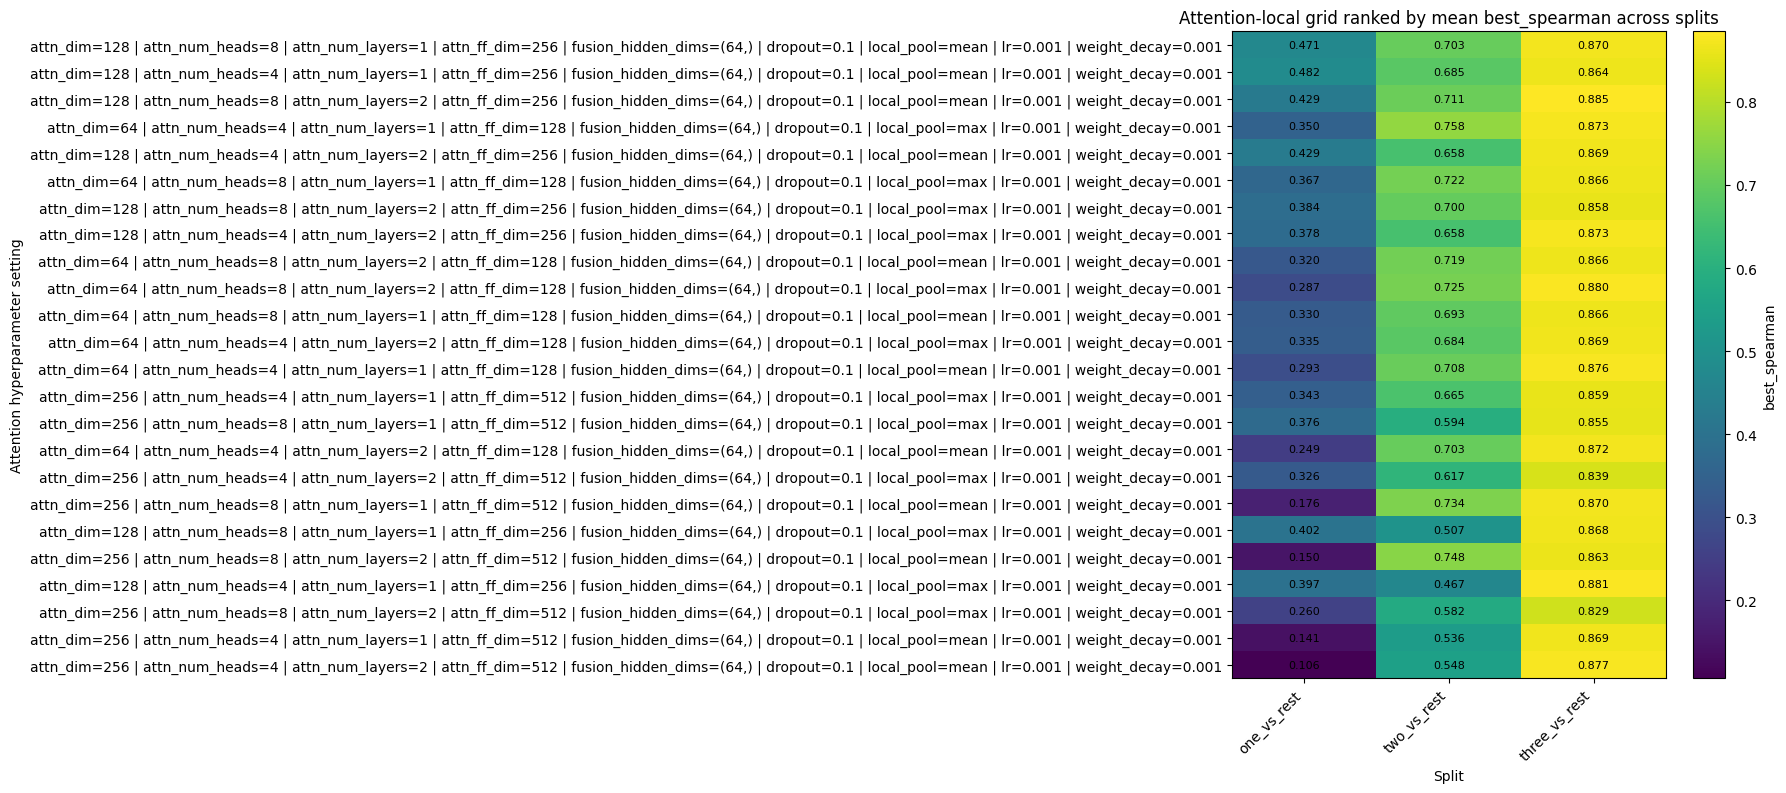

split,one_vs_rest,two_vs_rest,three_vs_rest
config_label,,,
"attn_dim=128 | attn_num_heads=8 | attn_num_layers=1 | attn_ff_dim=256 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=mean | lr=0.001 | weight_decay=0.001",0.470900,0.702754,0.870216
"attn_dim=128 | attn_num_heads=4 | attn_num_layers=1 | attn_ff_dim=256 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=mean | lr=0.001 | weight_decay=0.001",0.481602,0.685089,0.863750
"attn_dim=128 | attn_num_heads=8 | attn_num_layers=2 | attn_ff_dim=256 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=mean | lr=0.001 | weight_decay=0.001",0.428728,0.711387,0.884812
"attn_dim=64 | attn_num_heads=4 | attn_num_layers=1 | attn_ff_dim=128 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=max | lr=0.001 | weight_decay=0.001",0.350065,0.757826,0.873421
"attn_dim=128 | attn_num_heads=4 | attn_num_layers=2 | attn_ff_dim=256 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=mean | lr=0.001 | weight_decay=0.001",0.429305,0.657796,0.868644
"attn_dim=64 | attn_num_heads=8 | attn_num_layers=1 | attn_ff_dim=128 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=max | lr=0.001 | weight_decay=0.001",0.367364,0.721913,0.866035
"attn_dim=128 | attn_num_heads=8 | attn_num_layers=2 | attn_ff_dim=256 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=max | lr=0.001 | weight_decay=0.001",0.383966,0.699602,0.857692
"attn_dim=128 | attn_num_heads=4 | attn_num_layers=2 | attn_ff_dim=256 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=max | lr=0.001 | weight_decay=0.001",0.378023,0.658460,0.872660
"attn_dim=64 | attn_num_heads=8 | attn_num_layers=2 | attn_ff_dim=128 | fusion_hidden_dims=(64,) | dropout=0.1 | local_pool=mean | lr=0.001 | weight_decay=0.001",0.320385,0.718744,0.865505


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Heatmap for attention-local grid results
# One row per attention hyperparameter setting, ranked by mean across splits
# ---------------------------------------------------------------------

df = attn_grid_results_df.copy()

metric_col = "best_spearman"

if metric_col not in df.columns:
    raise ValueError(
        f"Could not find {metric_col}. Available columns are:\n{df.columns.tolist()}"
    )

# Identify split column
possible_split_cols = ["split", "split_name"]

split_col = None
for col in possible_split_cols:
    if col in df.columns:
        split_col = col
        break

if split_col is None:
    raise ValueError(
        f"Could not find split column. Available columns are:\n{df.columns.tolist()}"
    )

# ---------------------------------------------------------------------
# Use true hyperparameter columns, not run_name/name
# ---------------------------------------------------------------------

candidate_hparam_cols = [
    "attn_dim",
    "attn_num_heads",
    "attn_num_layers",
    "attn_ff_dim",
    "fusion_hidden_dims",
    "dropout",
    "local_pool",
    "lr",
    "weight_decay",
]

hparam_cols = [c for c in candidate_hparam_cols if c in df.columns]

if not hparam_cols:
    raise ValueError(
        "Could not find hyperparameter columns to group by. "
        f"Available columns are:\n{df.columns.tolist()}"
    )

print("Using hyperparameter columns:")
print(hparam_cols)

def make_config_label(row):
    return " | ".join([f"{c}={row[c]}" for c in hparam_cols])

df["config_label"] = df.apply(make_config_label, axis=1)

# Sanity check: each config should ideally have 3 splits
split_counts = (
    df.groupby("config_label")[split_col]
    .nunique()
    .sort_values(ascending=False)
)

print("\nNumber of splits found per config:")
display(split_counts.value_counts().sort_index())

# ---------------------------------------------------------------------
# Pivot to config x split
# ---------------------------------------------------------------------

heatmap_df = df.pivot_table(
    index="config_label",
    columns=split_col,
    values=metric_col,
    aggfunc="mean",
)

# Enforce split order
preferred_split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
existing_order = [s for s in preferred_split_order if s in heatmap_df.columns]
remaining_cols = [c for c in heatmap_df.columns if c not in existing_order]
heatmap_df = heatmap_df[existing_order + remaining_cols]

# Rank by mean across splits, but do not plot the mean as a column
rank_mean = heatmap_df.mean(axis=1, skipna=True)
heatmap_df = heatmap_df.loc[rank_mean.sort_values(ascending=False).index]

# Optional: only show top N
TOP_N = None  # e.g., 20
if TOP_N is not None:
    heatmap_df = heatmap_df.head(TOP_N)

# ---------------------------------------------------------------------
# Plot heatmap
# ---------------------------------------------------------------------

plot_df = heatmap_df.copy()

fig_height = max(6, 0.35 * len(plot_df))
fig_width = max(7, 1.7 * len(plot_df.columns))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)

ax.set_title(f"Attention-local grid ranked by mean {metric_col} across splits")
ax.set_xlabel("Split")
ax.set_ylabel("Attention hyperparameter setting")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(metric_col)

# Annotate values
for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        val = plot_df.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

plt.tight_layout()
plt.show()

heatmap_df

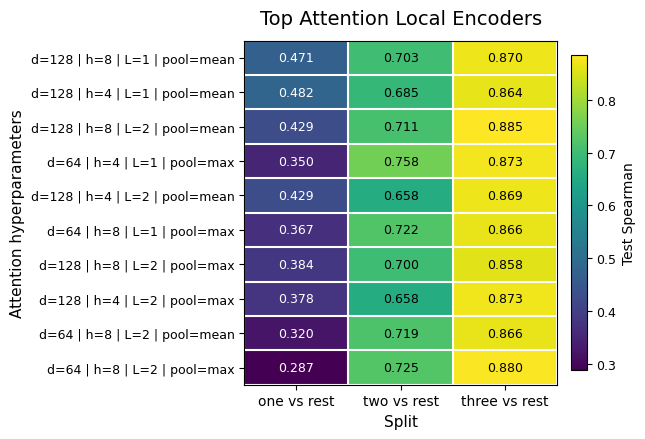

split,one_vs_rest,two_vs_rest,three_vs_rest
config_label,,,
d=128 | h=8 | L=1 | pool=mean,0.470900,0.702754,0.870216
d=128 | h=4 | L=1 | pool=mean,0.481602,0.685089,0.863750
d=128 | h=8 | L=2 | pool=mean,0.428728,0.711387,0.884812
d=64 | h=4 | L=1 | pool=max,0.350065,0.757826,0.873421
d=128 | h=4 | L=2 | pool=mean,0.429305,0.657796,0.868644
d=64 | h=8 | L=1 | pool=max,0.367364,0.721913,0.866035
d=128 | h=8 | L=2 | pool=max,0.383966,0.699602,0.857692
d=128 | h=4 | L=2 | pool=max,0.378023,0.658460,0.872660
d=64 | h=8 | L=2 | pool=mean,0.320385,0.718744,0.865505


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Presentation-ready attention heatmap
# ---------------------------------------------------------------------

df_plot = attn_grid_results_df.copy()

metric_col = "best_spearman"

if metric_col not in df_plot.columns:
    raise ValueError(
        f"Could not find {metric_col}. Available columns are:\n{df_plot.columns.tolist()}"
    )

# Identify split column
possible_split_cols = ["split", "split_name"]

split_col = None
for col in possible_split_cols:
    if col in df_plot.columns:
        split_col = col
        break

if split_col is None:
    raise ValueError(
        f"Could not find split column. Available columns are:\n{df_plot.columns.tolist()}"
    )

# ---------------------------------------------------------------------
# Compact attention-only labels
# ---------------------------------------------------------------------

required_cols = [
    "attn_dim",
    "attn_num_heads",
    "attn_num_layers",
    "local_pool",
]

missing = [c for c in required_cols if c not in df_plot.columns]
if missing:
    raise ValueError(f"Missing required columns for compact labels: {missing}")

def make_compact_attn_label(row):
    return (
        f"d={row['attn_dim']} | "
        f"h={row['attn_num_heads']} | "
        f"L={row['attn_num_layers']} | "
        f"pool={row['local_pool']}"
    )

df_plot["config_label"] = df_plot.apply(make_compact_attn_label, axis=1)

# ---------------------------------------------------------------------
# Pivot to one row per attention setting and rank by mean across splits
# ---------------------------------------------------------------------

heatmap_df = df_plot.pivot_table(
    index="config_label",
    columns=split_col,
    values=metric_col,
    aggfunc="mean",
)

preferred_split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
existing_order = [s for s in preferred_split_order if s in heatmap_df.columns]
remaining_cols = [c for c in heatmap_df.columns if c not in existing_order]
heatmap_df = heatmap_df[existing_order + remaining_cols]

rank_mean = heatmap_df.mean(axis=1, skipna=True)
heatmap_df = heatmap_df.loc[rank_mean.sort_values(ascending=False).index]

TOP_N = 10
heatmap_df = heatmap_df.head(TOP_N)

plot_df = heatmap_df.copy()

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig_height = max(4.5, 0.42 * len(plot_df))
fig_width = 6.5

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(
    [str(c).replace("_", " ") for c in plot_df.columns],
    fontsize=10,
)

ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index, fontsize=9)

ax.set_title(
    "Top Attention Local Encoders",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("Attention hyperparameters", fontsize=11)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Test Spearman", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ---------------------------------------------------------------------
# Adaptive annotation color
# ---------------------------------------------------------------------

values = plot_df.values.astype(float)
valid_values = values[~np.isnan(values)]

text_color_threshold = valid_values.min() + 0.5 * (
    valid_values.max() - valid_values.min()
)

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        val = plot_df.iloc[i, j]
        if pd.notna(val):
            text_color = "white" if val < text_color_threshold else "black"

            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
            )

# Light cell boundaries
ax.set_xticks(np.arange(-0.5, plot_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_df.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

heatmap_df

## 12. Literature / previous-method benchmark plots

These values are carried over from the original notebook. Update the `Ridge`, `MLP`, or new rows as you run additional architectures.

In [56]:
lit_results = pd.DataFrame({
    'model': [
        'ESM1v_perAA',
        'ESM1v_mean',
        'ESM1v_mutmean',
        'ESM2_attention',
        'Flat Ridge',
        'Flat MLP',
        'Fused MLP',
        'Fused CNN',
        'Fused Attention'
    ],
    'one_vs_rest': [0.28, 0.32, 0.19, 0.0, 0.416, 0.343, 0.395, 0.433, 0.471],
    'two_vs_rest': [0.28, 0.32, 0.19, 0.635, 0.642, 0.772, 0.730, 0.782, 0.703],
    'three_vs_rest': [0.82, 0.77, 0.80, 0.85, 0.831, 0.875, 0.869, 0.875, 0.870],
})

# If you ran the hybrid model section above, automatically append its best-Spearman row.
if 'hybrid_summary_wide' in globals():
    row = hybrid_summary_wide.copy()
    # Ensure all expected split columns exist even if you only ran one split.
    for split in ['one_vs_rest', 'two_vs_rest', 'three_vs_rest']:
        if split not in row.columns:
            row[split] = np.nan
    row = row[['model', 'one_vs_rest', 'two_vs_rest', 'three_vs_rest']]
    lit_results = pd.concat([lit_results, row], ignore_index=True)

# Add your future models by appending rows to lit_results.
display(lit_results)

,model,one_vs_rest,two_vs_rest,three_vs_rest
0,ESM1v_perAA,0.280,0.280,0.820
1,ESM1v_mean,0.320,0.320,0.770
2,ESM1v_mutmean,0.190,0.190,0.800
3,ESM2_attention,0.000,0.635,0.850
4,Flat Ridge,0.416,0.642,0.831
5,Flat MLP,0.343,0.772,0.875
6,Fused MLP,0.395,0.730,0.869
7,Fused CNN,0.433,0.782,0.875
8,Fused Attention,0.471,0.703,0.870


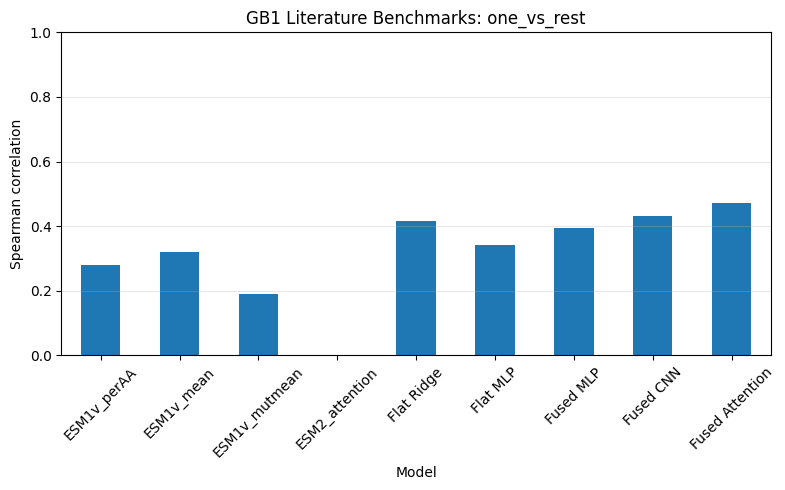

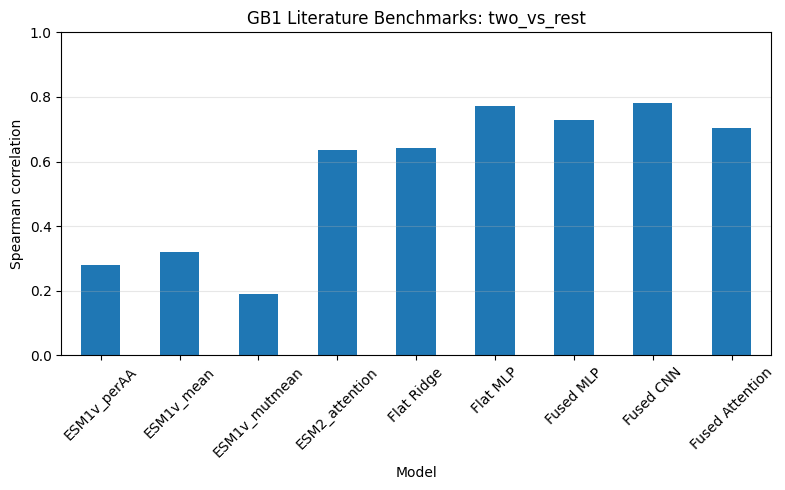

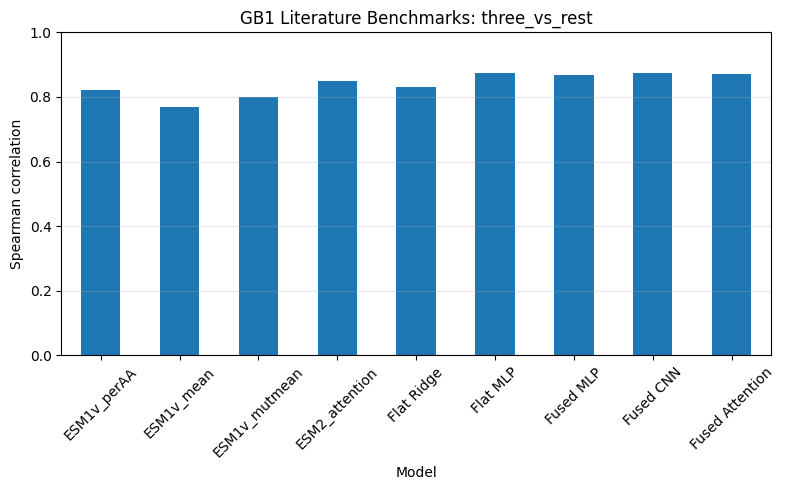

In [57]:
# One bar chart per split
split_order = ['one_vs_rest', 'two_vs_rest', 'three_vs_rest']
highlight_models = {'Ridge', 'MLP'}

for split in split_order:
    plot_series = lit_results.set_index('model')[split]

    fig, ax = plt.subplots(figsize=(8, 5))
    plot_series.plot(kind='bar', ax=ax, rot=45)

    ax.set_title(f'GB1 Literature Benchmarks: {split}')
    ax.set_ylabel('Spearman correlation')
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

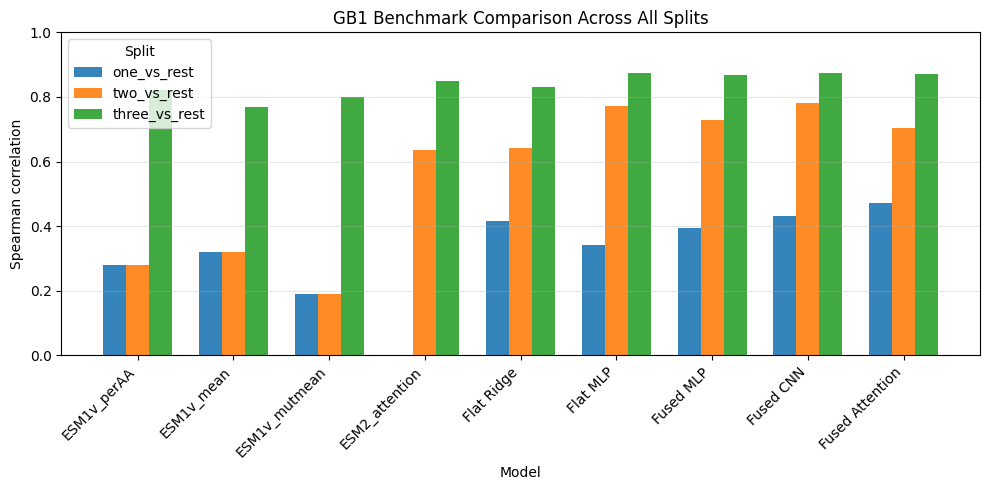

In [58]:
# Grouped comparison across all splits
models = lit_results['model'].tolist()
x = np.arange(len(models))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))

for i, split in enumerate(split_order):
    values = lit_results[split].values
    bars = ax.bar(
        x + (i - 1) * width,
        values,
        width=width,
        label=split,
        alpha=0.9,
    )

    for j, bar in enumerate(bars):
        if models[j] in highlight_models:
            bar.set_edgecolor('black')
            bar.set_linewidth(1.5)

ax.set_title('GB1 Benchmark Comparison Across All Splits')
ax.set_ylabel('Spearman correlation')
ax.set_xlabel('Model')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Split')

plt.tight_layout()
plt.show()

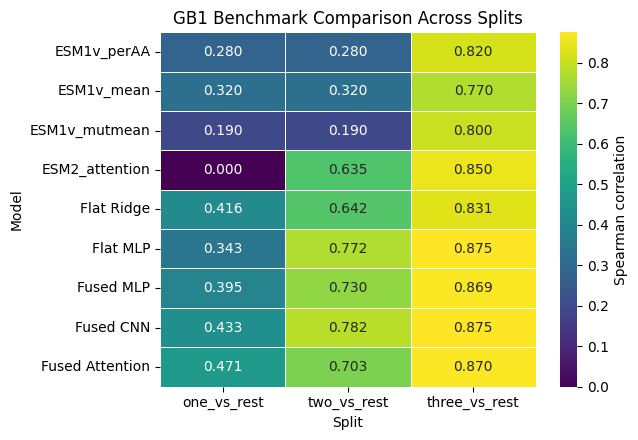

In [59]:
# Heatmap version
heatmap_df = lit_results.set_index('model')

plt.figure(figsize=(6.5, 4.5))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'},
)

ax.set_title('GB1 Benchmark Comparison Across Splits')
ax.set_xlabel('Split')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## Notes / caveats

- The final MLP sweep in the old notebook used `X_k5`, not `X_window_k5`. That means the MLP input was flat: full-sequence mean + flattened k=5 mutation window.
- `X_window_k5` is included because it is likely the more natural representation for architectures that treat the mutation neighborhood as a sequence of residue embeddings.
- The mutation positions `[38, 39, 40, 53]` are copied from the original notebook and are used as Python/zero-based indices.
- The benchmark values are hard-coded from the old notebook; update them as you generate new results.
- The hybrid training section uses the merged local sequence shape `(batch, local_len, embed_dim)`, e.g. `(batch, 24, 640)`, so overlapping k=5 windows are not duplicated as separate mutation-centered windows.
- The `best_spearman` in the hybrid section is selected on the test split for quick exploratory comparison. For a formal benchmark, add a train/validation/test split or nested validation procedure.